# Analisi delle Repository relative ai Context File

Notebook per analizzare `git_history_diffs.json` con:
1. Grafico globale degli status dei context file.
2. Sezioni per ogni repository con contributor, top commit context-file e commit con più modifiche.

In [21]:
import json
from pathlib import Path
import re
import os
import urllib.request
import urllib.error
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.style.use('seaborn-v0_8-whitegrid')

json_candidates = [
    Path(r"D:\\Progetti\\ContextWare\\data-manipulation\\outputs\\git_history_diffs.json"),
    Path("../../outputs/git_history_diffs.json"),
    Path("../outputs/git_history_diffs.json"),
    Path("outputs/git_history_diffs.json"),
]

json_path = next((p for p in json_candidates if p.exists()), None)
if json_path is None:
    raise FileNotFoundError("File git_history_diffs.json non trovato")

with json_path.open(encoding="utf-8") as f:
    raw_data = json.load(f)

rows = []
for repo_item in raw_data:
    repo = repo_item.get("repo")
    for commit in repo_item.get("acf_commits", []):
        commit_hash = commit.get("hash")
        commit_url = commit.get("url")
        for acf_file in commit.get("acf_files", []):
            rows.append({
                "repo": repo,
                "hash": commit_hash,
                "url": commit_url,
                "filename": acf_file.get("filename"),
                "status": acf_file.get("status"),
                "additions": acf_file.get("additions", 0),
                "deletions": acf_file.get("deletions", 0),
                "changes": acf_file.get("changes", 0),
            })

acf_df = pd.DataFrame(rows)
if acf_df.empty:
    raise ValueError("Nessun dato ACF trovato nel file JSON")

repo_history_dir = json_path.parent / "repo_history"
history_pattern = re.compile(r"^(?P<hash>[0-9a-f]{40}) \| (?P<date>[^|]+) \| (?P<author>[^|]+) \| (?P<message>.*) \| (?P<url>https?://.*)$")

history_rows = []
def read_lines_with_fallback(path: Path):
    data = path.read_bytes()
    best_text = None
    best_errors = None
    for enc in ("utf-8", "utf-8-sig", "cp1252", "latin-1"):
        try:
            text = data.decode(enc)
        except UnicodeDecodeError:
            text = data.decode(enc, errors="replace")
        errors = text.count(chr(0xFFFD))
        if best_errors is None or errors < best_errors:
            best_text = text
            best_errors = errors
            if errors == 0:
                break
    return best_text.splitlines() if best_text is not None else []

if repo_history_dir.exists():
    for txt_file in repo_history_dir.glob("*.txt"):
        repo_name = txt_file.stem.replace("__", "/")
        for line in read_lines_with_fallback(txt_file):
            line = line.strip()
            m = history_pattern.match(line)
            if m:
                item = m.groupdict()
                item["repo"] = repo_name
                history_rows.append(item)

history_df = pd.DataFrame(history_rows)
if not history_df.empty:
    history_df = history_df[["repo", "hash", "date", "author", "message", "url"]]
else:
    history_df = pd.DataFrame(columns=["repo", "hash", "date", "author", "message", "url"])

def clean_text(text):
    if pd.isna(text):
        return text
    text = str(text)
    text = text.replace(chr(0xFFFD), "")
    text = " ".join(text.split())
    return text

if not history_df.empty:
    history_df["message"] = history_df["message"].apply(clean_text)
    history_df["author"] = history_df["author"].apply(clean_text)

def load_env_files(paths):
    for path in paths:
        if not os.path.exists(path):
            continue
        with open(path, "r", encoding="utf-8") as handle:
            for raw in handle:
                line = raw.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                key, value = line.split("=", 1)
                key = key.strip()
                value = value.strip().strip('"').strip("'")
                if key and key not in os.environ:
                    os.environ[key] = value


def fetch_commit_info(owner, repo, sha, token):
    url = f"https://api.github.com/repos/{owner}/{repo}/commits/{sha}"
    headers = {
        "Accept": "application/vnd.github+json",
        "X-GitHub-Api-Version": "2022-11-28",
        "User-Agent": "contextware-report",
    }
    if token:
        headers["Authorization"] = f"Bearer {token}"
    req = urllib.request.Request(url, headers=headers)
    try:
        with urllib.request.urlopen(req) as resp:
            body = resp.read().decode("utf-8")
    except urllib.error.HTTPError:
        return None
    data = json.loads(body) if body else {}
    commit = data.get("commit") or {}
    author = commit.get("author") or {}
    committer = commit.get("committer") or {}
    date = author.get("date") or committer.get("date") or ""
    name = author.get("name") or committer.get("name") or ""
    message = (commit.get("message") or "").splitlines()[0]
    return {"message": message, "author": name, "date": date}


def refresh_messages_for_repo(history_df, repo_name, hashes, token_env="GITHUB_TOKEN"):
    if not hashes:
        return history_df
    load_env_files([".env", os.path.join(".contextWare", ".env")])
    token = os.environ.get(token_env)
    owner, repo = repo_name.split("/", 1)

    repo_rows = history_df[history_df["repo"] == repo_name]
    existing_messages = dict(zip(repo_rows["hash"], repo_rows["message"]))

    targets = []
    for sha in hashes:
        msg = existing_messages.get(sha)
        if msg is None:
            targets.append(sha)
            continue
        if str(msg).count("?") >= 3:
            targets.append(sha)

    if not targets:
        return history_df

    for sha in targets:
        info = fetch_commit_info(owner, repo, sha, token)
        if not info:
            continue
        message = clean_text(info.get("message"))
        author = clean_text(info.get("author"))
        date = clean_text(info.get("date"))
        mask = (history_df["repo"] == repo_name) & (history_df["hash"] == sha)
        if mask.any():
            if message:
                history_df.loc[mask, "message"] = message
            if author:
                history_df.loc[mask, "author"] = author
            if date:
                history_df.loc[mask, "date"] = date
        else:
            history_df = pd.concat(
                [
                    history_df,
                    pd.DataFrame(
                        [
                            {
                                "repo": repo_name,
                                "hash": sha,
                                "date": date,
                                "author": author,
                                "message": message,
                                "url": f"https://github.com/{repo_name}/commit/{sha}",
                            }
                        ]
                    ),
                ],
                ignore_index=True,
            )

    return history_df


# Fix mojibake in bannzai repo messages by re-fetching from GitHub.
bannzai_repo = "bannzai/SwiftTUI"
bannzai_hashes = (
    acf_df.loc[acf_df["repo"] == bannzai_repo, "hash"].dropna().unique().tolist()
)
if bannzai_hashes:
    history_df = refresh_messages_for_repo(history_df, bannzai_repo, bannzai_hashes)

commit_context_df = (
    acf_df.groupby(["repo", "hash", "url"], as_index=False)
    .agg(
        context_files=("filename", "count"),
        additions=("additions", "sum"),
        deletions=("deletions", "sum"),
        changes=("changes", "sum"),
    )
)

if not history_df.empty:
    commit_context_df = commit_context_df.merge(
        history_df[["repo", "hash", "author", "date", "message"]],
        on=["repo", "hash"],
        how="left",
    )
else:
    commit_context_df["author"] = "N/A"
    commit_context_df["date"] = "N/A"
    commit_context_df["message"] = "N/A"

display(Markdown(f"**Sorgente dati:** `{json_path}`"))
display(Markdown(f"**Repository analizzate:** {acf_df['repo'].nunique()}"))

**Sorgente dati:** `D:\Progetti\ContextWare\data-manipulation\outputs\git_history_diffs.json`

**Repository analizzate:** 17

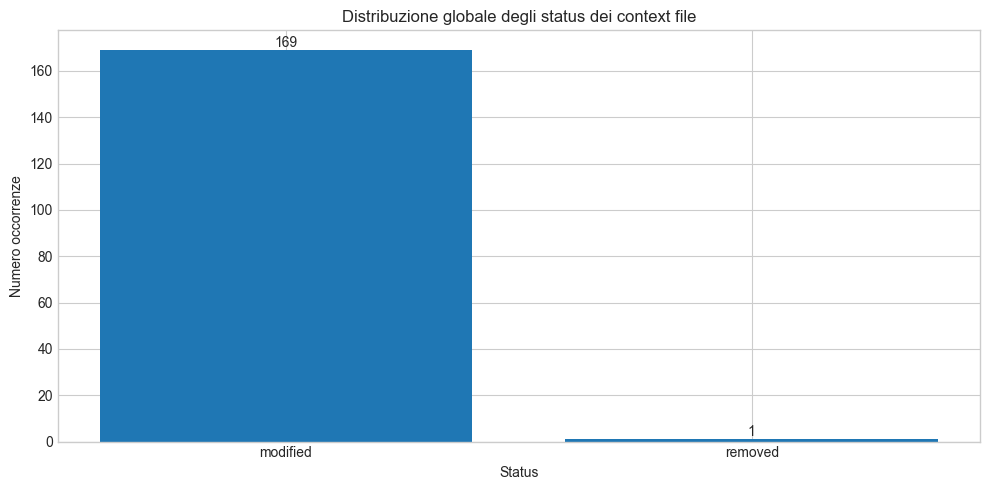

,count
status,
modified,169
removed,1


In [2]:
status_counts = acf_df["status"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(status_counts.index, status_counts.values)
ax.set_title("Distribuzione globale degli status dei context file")
ax.set_xlabel("Status")
ax.set_ylabel("Numero occorrenze")
ax.bar_label(bars)
plt.tight_layout()
plt.show()

display(status_counts.rename_axis("status").to_frame("count"))

In [3]:
def show_repo_report(repo_name: str, top_n: int = 10):
    display(Markdown(f"## {repo_name}"))

    repo_commits = commit_context_df[commit_context_df["repo"] == repo_name].copy()
    if repo_commits.empty:
        display(Markdown("Nessun commit context-file trovato."))
        return

    display(Markdown("### Contributor nella repository"))
    if not history_df.empty:
        repo_contributors = (
            history_df[history_df["repo"] == repo_name]["author"]
            .value_counts()
            .head(top_n)
            .sort_values(ascending=True)
        )
        if not repo_contributors.empty:
            fig, ax = plt.subplots(figsize=(10, max(3, len(repo_contributors) * 0.45)))
            bars = ax.barh(repo_contributors.index, repo_contributors.values)
            ax.set_title(f"Top contributor per commit - {repo_name}")
            ax.set_xlabel("Numero commit nella repository")
            ax.set_ylabel("Contributor")
            ax.bar_label(bars)
            plt.tight_layout()
            plt.show()
        else:
            display(Markdown("Nessun contributor trovato."))
    else:
        display(Markdown("Dati contributor non disponibili (repo_history mancante)."))

    display(Markdown("### Top commit relativi ai context file (per numero di context file toccati)"))
    top_context_commits = (
        repo_commits.sort_values(["context_files", "changes"], ascending=False)
        [["hash", "author", "date", "context_files", "additions", "deletions", "changes", "message", "url"]]
        .head(top_n)
        .reset_index(drop=True)
    )
    with pd.option_context('display.max_colwidth', None, 'display.max_rows', None, 'display.width', None):
        display(top_context_commits)

    display(Markdown("### Commit context-file con maggiori modifiche (additions + deletions)"))
    top_changes = (
        repo_commits.sort_values("changes", ascending=False)
        [["hash", "author", "date", "changes", "additions", "deletions", "context_files", "message", "url"]]
        .head(top_n)
        .reset_index(drop=True)
    )
    with pd.option_context('display.max_colwidth', None, 'display.max_rows', None, 'display.width', None):
        display(top_changes)

## BMPixel/cui

### Contributor nella repository

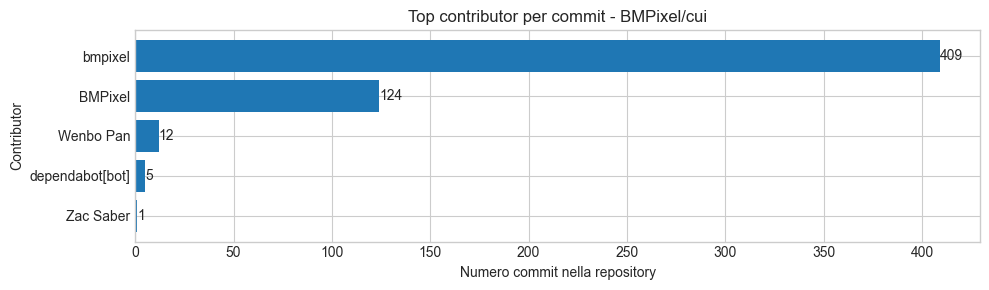

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,a09cf067a8681c73e6ef6b07a8f995f7bc71e7ff,bmpixel,2025-08-07T03:06:29Z,1,75,98,173,tests: revert to jest tests,https://github.com/wbopan/cui/compare/68d3a6d90e6a2751007f764dbf90bde277231985...a09cf067a8681c73e6ef6b07a8f995f7bc71e7ff
1,68d3a6d90e6a2751007f764dbf90bde277231985,bmpixel,2025-08-04T06:20:49Z,1,16,16,32,docs: update CLAUDE.md to use bun,https://github.com/wbopan/cui/compare/7871395b2265780f5da504cc98e8911fd09ad383...68d3a6d90e6a2751007f764dbf90bde277231985
2,a745b344577ba2306fae4decaebcee1677c9e926,bmpixel,2025-07-27T09:34:55Z,1,5,1,6,docs: update README.md,https://github.com/wbopan/cui/compare/3c767e80067e728367b7f8a39edfb7416ea10370...a745b344577ba2306fae4decaebcee1677c9e926
3,0488e3d853c542e5032639f717d58f5f7601797c,bmpixel,2025-07-30T04:46:23Z,1,2,2,4,docs: update design description,https://github.com/wbopan/cui/compare/3d2d011d39a7b293cd805d5ba985f27ab67d4b0d...0488e3d853c542e5032639f717d58f5f7601797c
4,3c767e80067e728367b7f8a39edfb7416ea10370,bmpixel,2025-07-27T05:44:59Z,1,3,1,4,refactor: improve production architecture by separating dev and prod static serving,https://github.com/wbopan/cui/compare/466ae95e707dd25f4784a4999740c73268b74cf9...3c767e80067e728367b7f8a39edfb7416ea10370
5,3d2d011d39a7b293cd805d5ba985f27ab67d4b0d,bmpixel,2025-07-30T03:36:57Z,1,2,1,3,test: remove gemini api test,https://github.com/wbopan/cui/compare/039c5be43143556fde06f9bbb0fa0570acca0259...3d2d011d39a7b293cd805d5ba985f27ab67d4b0d
6,7871395b2265780f5da504cc98e8911fd09ad383,bmpixel,2025-07-30T06:17:13Z,1,2,1,3,Merge branch 'dev' into main,https://github.com/wbopan/cui/compare/0488e3d853c542e5032639f717d58f5f7601797c...7871395b2265780f5da504cc98e8911fd09ad383
7,039c5be43143556fde06f9bbb0fa0570acca0259,bmpixel,2025-07-28T09:50:49Z,1,1,1,2,refactor: rename console to inspector and logwindow to logmonitor,https://github.com/wbopan/cui/compare/a745b344577ba2306fae4decaebcee1677c9e926...039c5be43143556fde06f9bbb0fa0570acca0259
8,1fdbcacfae48558a7041dbb1d2a36f7163ed2a79,bmpixel,2025-08-08T11:45:17Z,1,1,1,2,docs: update references from Claude Code Web UI to Common Agent UI,https://github.com/wbopan/cui/compare/53b39884529c68caac3f163a437b3adaac615514...1fdbcacfae48558a7041dbb1d2a36f7163ed2a79
9,53b39884529c68caac3f163a437b3adaac615514,bmpixel,2025-08-07T07:07:47Z,1,1,1,2,chore: update testing framework from Jest to Vitest and adjust configurations,https://github.com/wbopan/cui/compare/a09cf067a8681c73e6ef6b07a8f995f7bc71e7ff...53b39884529c68caac3f163a437b3adaac615514


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,a09cf067a8681c73e6ef6b07a8f995f7bc71e7ff,bmpixel,2025-08-07T03:06:29Z,173,75,98,1,tests: revert to jest tests,https://github.com/wbopan/cui/compare/68d3a6d90e6a2751007f764dbf90bde277231985...a09cf067a8681c73e6ef6b07a8f995f7bc71e7ff
1,68d3a6d90e6a2751007f764dbf90bde277231985,bmpixel,2025-08-04T06:20:49Z,32,16,16,1,docs: update CLAUDE.md to use bun,https://github.com/wbopan/cui/compare/7871395b2265780f5da504cc98e8911fd09ad383...68d3a6d90e6a2751007f764dbf90bde277231985
2,a745b344577ba2306fae4decaebcee1677c9e926,bmpixel,2025-07-27T09:34:55Z,6,5,1,1,docs: update README.md,https://github.com/wbopan/cui/compare/3c767e80067e728367b7f8a39edfb7416ea10370...a745b344577ba2306fae4decaebcee1677c9e926
3,0488e3d853c542e5032639f717d58f5f7601797c,bmpixel,2025-07-30T04:46:23Z,4,2,2,1,docs: update design description,https://github.com/wbopan/cui/compare/3d2d011d39a7b293cd805d5ba985f27ab67d4b0d...0488e3d853c542e5032639f717d58f5f7601797c
4,3c767e80067e728367b7f8a39edfb7416ea10370,bmpixel,2025-07-27T05:44:59Z,4,3,1,1,refactor: improve production architecture by separating dev and prod static serving,https://github.com/wbopan/cui/compare/466ae95e707dd25f4784a4999740c73268b74cf9...3c767e80067e728367b7f8a39edfb7416ea10370
5,3d2d011d39a7b293cd805d5ba985f27ab67d4b0d,bmpixel,2025-07-30T03:36:57Z,3,2,1,1,test: remove gemini api test,https://github.com/wbopan/cui/compare/039c5be43143556fde06f9bbb0fa0570acca0259...3d2d011d39a7b293cd805d5ba985f27ab67d4b0d
6,7871395b2265780f5da504cc98e8911fd09ad383,bmpixel,2025-07-30T06:17:13Z,3,2,1,1,Merge branch 'dev' into main,https://github.com/wbopan/cui/compare/0488e3d853c542e5032639f717d58f5f7601797c...7871395b2265780f5da504cc98e8911fd09ad383
7,039c5be43143556fde06f9bbb0fa0570acca0259,bmpixel,2025-07-28T09:50:49Z,2,1,1,1,refactor: rename console to inspector and logwindow to logmonitor,https://github.com/wbopan/cui/compare/a745b344577ba2306fae4decaebcee1677c9e926...039c5be43143556fde06f9bbb0fa0570acca0259
8,53b39884529c68caac3f163a437b3adaac615514,bmpixel,2025-08-07T07:07:47Z,2,1,1,1,chore: update testing framework from Jest to Vitest and adjust configurations,https://github.com/wbopan/cui/compare/a09cf067a8681c73e6ef6b07a8f995f7bc71e7ff...53b39884529c68caac3f163a437b3adaac615514
9,1fdbcacfae48558a7041dbb1d2a36f7163ed2a79,bmpixel,2025-08-08T11:45:17Z,2,1,1,1,docs: update references from Claude Code Web UI to Common Agent UI,https://github.com/wbopan/cui/compare/53b39884529c68caac3f163a437b3adaac615514...1fdbcacfae48558a7041dbb1d2a36f7163ed2a79


In [4]:
show_repo_report("BMPixel/cui")

## CIRISAI/CIRISAgent

### Contributor nella repository

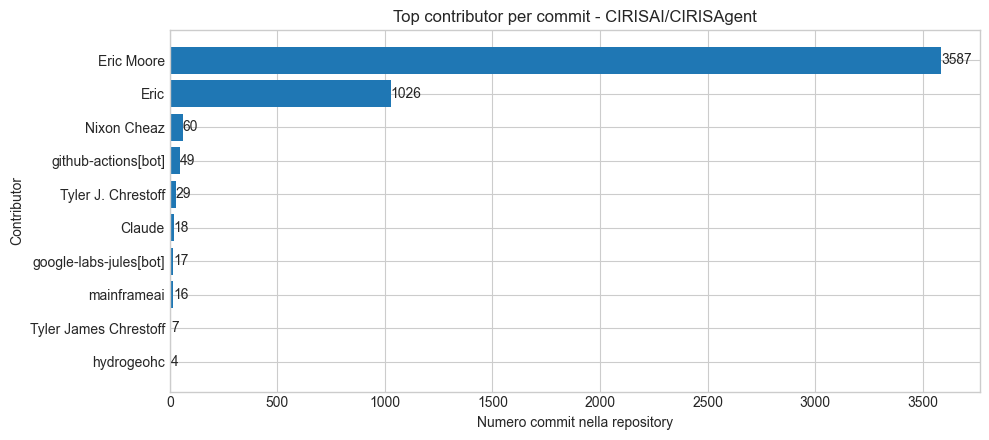

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,bdeed0bfe5c254c19856cdfaade5dc1d45ccd30f,Eric,2026-03-29T01:07:22Z,1,134,1,135,"Release 2.3.0: HA/MA Tool Documentation, Audit Trail Improvements (#650)",https://github.com/CIRISAI/CIRISAgent/compare/9d80d0300dad0872646bed5f1cda8feeb7668847...bdeed0bfe5c254c19856cdfaade5dc1d45ccd30f
1,b7f9adf3e1b0ee07dcc4433ef0684dbd9f3da074,Eric,2026-04-28T21:21:10Z,1,38,0,38,"Release 2.7.4: production hotfix ? Groq cap, retry remediation, gemma-4 reasoning, DSDMA cleanup (#702)",https://github.com/CIRISAI/CIRISAgent/compare/6c13f88c65fb7e28ca33e60215daaca2fea2c9a2...b7f9adf3e1b0ee07dcc4433ef0684dbd9f3da074
2,60a34974d548a741c05a16b15ab4024f22003be1,Eric,2026-04-20T17:03:10Z,1,13,13,26,"Release 2.6.0: Android logcat fix, WASM infrastructure, audit chain verification (#680)",https://github.com/CIRISAI/CIRISAgent/compare/8116742483ba0b4bb858e96ba83c1b3724c291ec...60a34974d548a741c05a16b15ab4024f22003be1
3,50bf5c8b9acdef67fbd7f04a72f6c9c2437a3c3a,NaN,NaN,1,25,0,25,NaN,https://github.com/CIRISAI/CIRISAgent/compare/b7f9adf3e1b0ee07dcc4433ef0684dbd9f3da074...50bf5c8b9acdef67fbd7f04a72f6c9c2437a3c3a
4,97d071a478a8112005921b44fa2c24ecf28b49bb,Eric Moore,2026-04-08T00:39:59Z,1,12,0,12,"Fix indentation in wallet providers, add 2.4.0 changelog",https://github.com/CIRISAI/CIRISAgent/compare/13b085d2a36cb50811e6afe84ab791f60e2d08e6...97d071a478a8112005921b44fa2c24ecf28b49bb
5,13b085d2a36cb50811e6afe84ab791f60e2d08e6,Eric,2026-04-07T14:22:59Z,1,6,3,9,Release 2.3.7 - OAuth consent node fix and test updates (#662),https://github.com/CIRISAI/CIRISAgent/compare/bdeed0bfe5c254c19856cdfaade5dc1d45ccd30f...13b085d2a36cb50811e6afe84ab791f60e2d08e6
6,6c13f88c65fb7e28ca33e60215daaca2fea2c9a2,Eric,2026-04-25T16:11:29Z,1,7,2,9,"Update release 2.7.0 with QA, deferral, and mobile client fixes (#698)",https://github.com/CIRISAI/CIRISAgent/compare/60a34974d548a741c05a16b15ab4024f22003be1...6c13f88c65fb7e28ca33e60215daaca2fea2c9a2
7,8116742483ba0b4bb858e96ba83c1b3724c291ec,Eric Moore,2026-04-14T15:17:20Z,1,6,3,9,Remove fallback admin password from production code,https://github.com/CIRISAI/CIRISAgent/compare/58debb753290b8e5696f10fc0a1fbaf8f3168b03...8116742483ba0b4bb858e96ba83c1b3724c291ec
8,58debb753290b8e5696f10fc0a1fbaf8f3168b03,Eric,2026-04-10T13:58:33Z,1,2,2,4,Domain-aware deferral routing and pending deferrals UI (#668),https://github.com/CIRISAI/CIRISAgent/compare/97d071a478a8112005921b44fa2c24ecf28b49bb...58debb753290b8e5696f10fc0a1fbaf8f3168b03
9,59fa991c1beaf3541389f1197c527e863fd2730f,NaN,NaN,1,1,1,2,NaN,https://github.com/CIRISAI/CIRISAgent/compare/50bf5c8b9acdef67fbd7f04a72f6c9c2437a3c3a...59fa991c1beaf3541389f1197c527e863fd2730f


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,bdeed0bfe5c254c19856cdfaade5dc1d45ccd30f,Eric,2026-03-29T01:07:22Z,135,134,1,1,"Release 2.3.0: HA/MA Tool Documentation, Audit Trail Improvements (#650)",https://github.com/CIRISAI/CIRISAgent/compare/9d80d0300dad0872646bed5f1cda8feeb7668847...bdeed0bfe5c254c19856cdfaade5dc1d45ccd30f
1,b7f9adf3e1b0ee07dcc4433ef0684dbd9f3da074,Eric,2026-04-28T21:21:10Z,38,38,0,1,"Release 2.7.4: production hotfix ? Groq cap, retry remediation, gemma-4 reasoning, DSDMA cleanup (#702)",https://github.com/CIRISAI/CIRISAgent/compare/6c13f88c65fb7e28ca33e60215daaca2fea2c9a2...b7f9adf3e1b0ee07dcc4433ef0684dbd9f3da074
2,60a34974d548a741c05a16b15ab4024f22003be1,Eric,2026-04-20T17:03:10Z,26,13,13,1,"Release 2.6.0: Android logcat fix, WASM infrastructure, audit chain verification (#680)",https://github.com/CIRISAI/CIRISAgent/compare/8116742483ba0b4bb858e96ba83c1b3724c291ec...60a34974d548a741c05a16b15ab4024f22003be1
3,50bf5c8b9acdef67fbd7f04a72f6c9c2437a3c3a,NaN,NaN,25,25,0,1,NaN,https://github.com/CIRISAI/CIRISAgent/compare/b7f9adf3e1b0ee07dcc4433ef0684dbd9f3da074...50bf5c8b9acdef67fbd7f04a72f6c9c2437a3c3a
4,97d071a478a8112005921b44fa2c24ecf28b49bb,Eric Moore,2026-04-08T00:39:59Z,12,12,0,1,"Fix indentation in wallet providers, add 2.4.0 changelog",https://github.com/CIRISAI/CIRISAgent/compare/13b085d2a36cb50811e6afe84ab791f60e2d08e6...97d071a478a8112005921b44fa2c24ecf28b49bb
5,13b085d2a36cb50811e6afe84ab791f60e2d08e6,Eric,2026-04-07T14:22:59Z,9,6,3,1,Release 2.3.7 - OAuth consent node fix and test updates (#662),https://github.com/CIRISAI/CIRISAgent/compare/bdeed0bfe5c254c19856cdfaade5dc1d45ccd30f...13b085d2a36cb50811e6afe84ab791f60e2d08e6
6,6c13f88c65fb7e28ca33e60215daaca2fea2c9a2,Eric,2026-04-25T16:11:29Z,9,7,2,1,"Update release 2.7.0 with QA, deferral, and mobile client fixes (#698)",https://github.com/CIRISAI/CIRISAgent/compare/60a34974d548a741c05a16b15ab4024f22003be1...6c13f88c65fb7e28ca33e60215daaca2fea2c9a2
7,8116742483ba0b4bb858e96ba83c1b3724c291ec,Eric Moore,2026-04-14T15:17:20Z,9,6,3,1,Remove fallback admin password from production code,https://github.com/CIRISAI/CIRISAgent/compare/58debb753290b8e5696f10fc0a1fbaf8f3168b03...8116742483ba0b4bb858e96ba83c1b3724c291ec
8,58debb753290b8e5696f10fc0a1fbaf8f3168b03,Eric,2026-04-10T13:58:33Z,4,2,2,1,Domain-aware deferral routing and pending deferrals UI (#668),https://github.com/CIRISAI/CIRISAgent/compare/97d071a478a8112005921b44fa2c24ecf28b49bb...58debb753290b8e5696f10fc0a1fbaf8f3168b03
9,59fa991c1beaf3541389f1197c527e863fd2730f,NaN,NaN,2,1,1,1,NaN,https://github.com/CIRISAI/CIRISAgent/compare/50bf5c8b9acdef67fbd7f04a72f6c9c2437a3c3a...59fa991c1beaf3541389f1197c527e863fd2730f


In [5]:
show_repo_report("CIRISAI/CIRISAgent")

## UMEP-dev/SUEWS

### Contributor nella repository

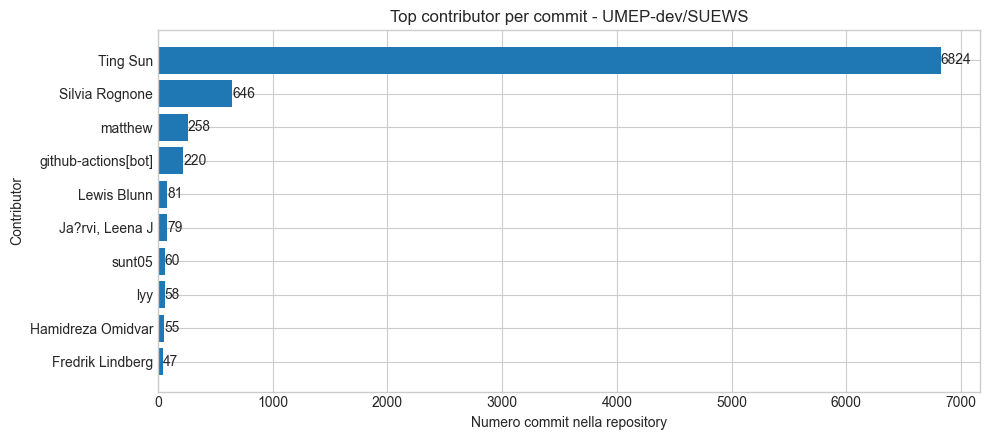

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,c21b90b8c1b3714995219d247c35a11f02f284d7,Ting Sun,2025-12-11T14:40:35Z,1,43,77,120,refactor: reorganise Claude config with path-conditional rules (#1025),https://github.com/UMEP-dev/SUEWS/compare/2bbd69e904b43cf1fff56b06a17f407b4d8d285f...c21b90b8c1b3714995219d247c35a11f02f284d7
1,cb227bee3615c0c2cca1ff6ed8bea5d471cf888f,Ting Sun,2026-01-02T20:40:18Z,1,31,55,86,Refactor: rename skills with -skill suffix and split SKILL.md (#1052),https://github.com/UMEP-dev/SUEWS/compare/c21b90b8c1b3714995219d247c35a11f02f284d7...cb227bee3615c0c2cca1ff6ed8bea5d471cf888f
2,02ce7d1fe1d55a8ce638745ad1461b30d49bb9a5,Ting Sun,2026-04-19T21:36:38Z,1,28,0,28,site: landing redesign + ancillary pages + brand footer + URL sweep (#1313),https://github.com/UMEP-dev/SUEWS/compare/171423d0cbb7ecabc5a4f702e1aebad9fe9a11f5...02ce7d1fe1d55a8ce638745ad1461b30d49bb9a5
3,c99e414c8cf8b19085bd2cf6966e1f75c558974e,Ting Sun,2026-01-16T07:08:14Z,1,11,13,24,chore: streamline skill structure (#1062),https://github.com/UMEP-dev/SUEWS/compare/cb227bee3615c0c2cca1ff6ed8bea5d471cf888f...c99e414c8cf8b19085bd2cf6966e1f75c558974e
4,2bbd69e904b43cf1fff56b06a17f407b4d8d285f,Ting Sun,2025-12-11T11:49:46Z,1,5,3,8,Enhance sync-docs skill with comprehensive data model checks (#1024),https://github.com/UMEP-dev/SUEWS/compare/66f17387416c10ca66d8ae7a50b305bf5b4701bb...2bbd69e904b43cf1fff56b06a17f407b4d8d285f
5,66f17387416c10ca66d8ae7a50b305bf5b4701bb,Ting Sun,2025-11-30T22:19:28Z,1,7,0,7,docs: update build system and developer documentation (#951),https://github.com/UMEP-dev/SUEWS/compare/64840b8a15b03c02e85a2812b69e0021e5101952...66f17387416c10ca66d8ae7a50b305bf5b4701bb
6,171423d0cbb7ecabc5a4f702e1aebad9fe9a11f5,Ting Sun,2026-04-03T20:24:44Z,1,1,3,4,Chore: trim repo skills and add Rust bridge rules (#1279),https://github.com/UMEP-dev/SUEWS/compare/b5dc4b5996331739d6f96277e646b02ce6c6be7d...171423d0cbb7ecabc5a4f702e1aebad9fe9a11f5
7,65f91f46d3e8ef96b9d52479c42117da315833cc,NaN,NaN,1,1,0,1,NaN,https://github.com/UMEP-dev/SUEWS/compare/02ce7d1fe1d55a8ce638745ad1461b30d49bb9a5...65f91f46d3e8ef96b9d52479c42117da315833cc
8,b5dc4b5996331739d6f96277e646b02ce6c6be7d,Ting Sun,2026-01-29T21:02:56Z,1,1,0,1,feat: add GitHub workflow skills and pre-commit quality gate (#1160),https://github.com/UMEP-dev/SUEWS/compare/d4bf2493a788a032836906b95c44da36dfa1e36f...b5dc4b5996331739d6f96277e646b02ce6c6be7d
9,d4bf2493a788a032836906b95c44da36dfa1e36f,Ting Sun,2026-01-23T13:49:53Z,1,1,0,1,docs(claude): add CI rules for fork PR handling (#1118),https://github.com/UMEP-dev/SUEWS/compare/c99e414c8cf8b19085bd2cf6966e1f75c558974e...d4bf2493a788a032836906b95c44da36dfa1e36f


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,c21b90b8c1b3714995219d247c35a11f02f284d7,Ting Sun,2025-12-11T14:40:35Z,120,43,77,1,refactor: reorganise Claude config with path-conditional rules (#1025),https://github.com/UMEP-dev/SUEWS/compare/2bbd69e904b43cf1fff56b06a17f407b4d8d285f...c21b90b8c1b3714995219d247c35a11f02f284d7
1,cb227bee3615c0c2cca1ff6ed8bea5d471cf888f,Ting Sun,2026-01-02T20:40:18Z,86,31,55,1,Refactor: rename skills with -skill suffix and split SKILL.md (#1052),https://github.com/UMEP-dev/SUEWS/compare/c21b90b8c1b3714995219d247c35a11f02f284d7...cb227bee3615c0c2cca1ff6ed8bea5d471cf888f
2,02ce7d1fe1d55a8ce638745ad1461b30d49bb9a5,Ting Sun,2026-04-19T21:36:38Z,28,28,0,1,site: landing redesign + ancillary pages + brand footer + URL sweep (#1313),https://github.com/UMEP-dev/SUEWS/compare/171423d0cbb7ecabc5a4f702e1aebad9fe9a11f5...02ce7d1fe1d55a8ce638745ad1461b30d49bb9a5
3,c99e414c8cf8b19085bd2cf6966e1f75c558974e,Ting Sun,2026-01-16T07:08:14Z,24,11,13,1,chore: streamline skill structure (#1062),https://github.com/UMEP-dev/SUEWS/compare/cb227bee3615c0c2cca1ff6ed8bea5d471cf888f...c99e414c8cf8b19085bd2cf6966e1f75c558974e
4,2bbd69e904b43cf1fff56b06a17f407b4d8d285f,Ting Sun,2025-12-11T11:49:46Z,8,5,3,1,Enhance sync-docs skill with comprehensive data model checks (#1024),https://github.com/UMEP-dev/SUEWS/compare/66f17387416c10ca66d8ae7a50b305bf5b4701bb...2bbd69e904b43cf1fff56b06a17f407b4d8d285f
5,66f17387416c10ca66d8ae7a50b305bf5b4701bb,Ting Sun,2025-11-30T22:19:28Z,7,7,0,1,docs: update build system and developer documentation (#951),https://github.com/UMEP-dev/SUEWS/compare/64840b8a15b03c02e85a2812b69e0021e5101952...66f17387416c10ca66d8ae7a50b305bf5b4701bb
6,171423d0cbb7ecabc5a4f702e1aebad9fe9a11f5,Ting Sun,2026-04-03T20:24:44Z,4,1,3,1,Chore: trim repo skills and add Rust bridge rules (#1279),https://github.com/UMEP-dev/SUEWS/compare/b5dc4b5996331739d6f96277e646b02ce6c6be7d...171423d0cbb7ecabc5a4f702e1aebad9fe9a11f5
7,65f91f46d3e8ef96b9d52479c42117da315833cc,NaN,NaN,1,1,0,1,NaN,https://github.com/UMEP-dev/SUEWS/compare/02ce7d1fe1d55a8ce638745ad1461b30d49bb9a5...65f91f46d3e8ef96b9d52479c42117da315833cc
8,b5dc4b5996331739d6f96277e646b02ce6c6be7d,Ting Sun,2026-01-29T21:02:56Z,1,1,0,1,feat: add GitHub workflow skills and pre-commit quality gate (#1160),https://github.com/UMEP-dev/SUEWS/compare/d4bf2493a788a032836906b95c44da36dfa1e36f...b5dc4b5996331739d6f96277e646b02ce6c6be7d
9,d4bf2493a788a032836906b95c44da36dfa1e36f,Ting Sun,2026-01-23T13:49:53Z,1,1,0,1,docs(claude): add CI rules for fork PR handling (#1118),https://github.com/UMEP-dev/SUEWS/compare/c99e414c8cf8b19085bd2cf6966e1f75c558974e...d4bf2493a788a032836906b95c44da36dfa1e36f


In [6]:
show_repo_report("UMEP-dev/SUEWS")

## baleen37/dotfiles

### Contributor nella repository

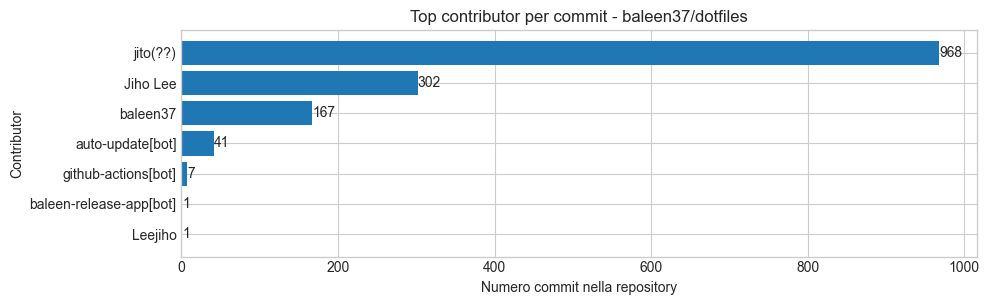

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,e85af00310b87d5d37d30652ed61e339dccb3e54,jito(??),2025-11-27T01:37:58Z,1,69,658,727,refactor: simplify CLAUDE.md and update code-reviewer agent (#906),https://github.com/baleen37/dotfiles/compare/fe736271d15c912b30694024f50ef488a4b1bebe...e85af00310b87d5d37d30652ed61e339dccb3e54
1,384fe62187e9495eeca2f5d2da150e285d0275a5,jito(??),2025-12-25T08:29:18Z,1,382,0,382,docs: Enhance CLAUDE.md with comprehensive architecture and development guide (#984),https://github.com/baleen37/dotfiles/compare/52a293916f5b23cdd915ae48936359a7bcb5ec73...384fe62187e9495eeca2f5d2da150e285d0275a5
2,52a293916f5b23cdd915ae48936359a7bcb5ec73,jito(??),2025-12-22T05:59:31Z,1,0,112,112,feat: add OpenCode support with Claude Code 2.0.67 pinning (#973),https://github.com/baleen37/dotfiles/compare/e85af00310b87d5d37d30652ed61e339dccb3e54...52a293916f5b23cdd915ae48936359a7bcb5ec73
3,0819b595b92f91a63d5592cfb528817e566c95e8,jito(??),2025-11-20T07:02:48Z,1,106,0,106,feat: implement comprehensive Nix test code improvement system (#886),https://github.com/baleen37/dotfiles/compare/4ec1ec6737c486dd96ed94a3e4d8ee54518e7ccb...0819b595b92f91a63d5592cfb528817e566c95e8
4,4ec1ec6737c486dd96ed94a3e4d8ee54518e7ccb,jito(??),2025-11-19T07:21:42Z,1,38,0,38,feat: add npm global PATH configuration and tests (#883),https://github.com/baleen37/dotfiles/compare/7950f5adcd8ccde0334cc0dcb70a5cba4b031932...4ec1ec6737c486dd96ed94a3e4d8ee54518e7ccb
5,db0a54b5ff8e05fcb991916ccefd3bb982bd35aa,jito(??),2026-04-20T23:51:12Z,1,10,0,10,feat(zsh): remove hardcoded default model from cc wrapper (#1221),https://github.com/baleen37/dotfiles/compare/81645af258f606d450f318cd6333661f5390ed57...db0a54b5ff8e05fcb991916ccefd3bb982bd35aa
6,fe736271d15c912b30694024f50ef488a4b1bebe,jito(??),2025-11-25T06:34:45Z,1,4,4,8,feat: IntelliJ IDEA background launcher with SSH agent integration + ghostty terminal (#898),https://github.com/baleen37/dotfiles/compare/0819b595b92f91a63d5592cfb528817e566c95e8...fe736271d15c912b30694024f50ef488a4b1bebe
7,10b4931b55ba0a6f53131ae51ab2d746d672d6b9,NaN,NaN,1,4,2,6,NaN,https://github.com/baleen37/dotfiles/compare/db0a54b5ff8e05fcb991916ccefd3bb982bd35aa...10b4931b55ba0a6f53131ae51ab2d746d672d6b9
8,81645af258f606d450f318cd6333661f5390ed57,jito(??),2026-02-23T06:08:28Z,1,1,1,2,refactor(gw): remove subcmd concept (#1131),https://github.com/baleen37/dotfiles/compare/b84ef2f3b650ecde5e37b237908a8e6b8eb56a9d...81645af258f606d450f318cd6333661f5390ed57
9,b84ef2f3b650ecde5e37b237908a8e6b8eb56a9d,jito(??),2026-02-05T03:10:47Z,1,1,1,2,docs(tmux): fix documentation to reflect Ctrl+a prefix,https://github.com/baleen37/dotfiles/compare/384fe62187e9495eeca2f5d2da150e285d0275a5...b84ef2f3b650ecde5e37b237908a8e6b8eb56a9d


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,e85af00310b87d5d37d30652ed61e339dccb3e54,jito(??),2025-11-27T01:37:58Z,727,69,658,1,refactor: simplify CLAUDE.md and update code-reviewer agent (#906),https://github.com/baleen37/dotfiles/compare/fe736271d15c912b30694024f50ef488a4b1bebe...e85af00310b87d5d37d30652ed61e339dccb3e54
1,384fe62187e9495eeca2f5d2da150e285d0275a5,jito(??),2025-12-25T08:29:18Z,382,382,0,1,docs: Enhance CLAUDE.md with comprehensive architecture and development guide (#984),https://github.com/baleen37/dotfiles/compare/52a293916f5b23cdd915ae48936359a7bcb5ec73...384fe62187e9495eeca2f5d2da150e285d0275a5
2,52a293916f5b23cdd915ae48936359a7bcb5ec73,jito(??),2025-12-22T05:59:31Z,112,0,112,1,feat: add OpenCode support with Claude Code 2.0.67 pinning (#973),https://github.com/baleen37/dotfiles/compare/e85af00310b87d5d37d30652ed61e339dccb3e54...52a293916f5b23cdd915ae48936359a7bcb5ec73
3,0819b595b92f91a63d5592cfb528817e566c95e8,jito(??),2025-11-20T07:02:48Z,106,106,0,1,feat: implement comprehensive Nix test code improvement system (#886),https://github.com/baleen37/dotfiles/compare/4ec1ec6737c486dd96ed94a3e4d8ee54518e7ccb...0819b595b92f91a63d5592cfb528817e566c95e8
4,4ec1ec6737c486dd96ed94a3e4d8ee54518e7ccb,jito(??),2025-11-19T07:21:42Z,38,38,0,1,feat: add npm global PATH configuration and tests (#883),https://github.com/baleen37/dotfiles/compare/7950f5adcd8ccde0334cc0dcb70a5cba4b031932...4ec1ec6737c486dd96ed94a3e4d8ee54518e7ccb
5,db0a54b5ff8e05fcb991916ccefd3bb982bd35aa,jito(??),2026-04-20T23:51:12Z,10,10,0,1,feat(zsh): remove hardcoded default model from cc wrapper (#1221),https://github.com/baleen37/dotfiles/compare/81645af258f606d450f318cd6333661f5390ed57...db0a54b5ff8e05fcb991916ccefd3bb982bd35aa
6,fe736271d15c912b30694024f50ef488a4b1bebe,jito(??),2025-11-25T06:34:45Z,8,4,4,1,feat: IntelliJ IDEA background launcher with SSH agent integration + ghostty terminal (#898),https://github.com/baleen37/dotfiles/compare/0819b595b92f91a63d5592cfb528817e566c95e8...fe736271d15c912b30694024f50ef488a4b1bebe
7,10b4931b55ba0a6f53131ae51ab2d746d672d6b9,NaN,NaN,6,4,2,1,NaN,https://github.com/baleen37/dotfiles/compare/db0a54b5ff8e05fcb991916ccefd3bb982bd35aa...10b4931b55ba0a6f53131ae51ab2d746d672d6b9
8,81645af258f606d450f318cd6333661f5390ed57,jito(??),2026-02-23T06:08:28Z,2,1,1,1,refactor(gw): remove subcmd concept (#1131),https://github.com/baleen37/dotfiles/compare/b84ef2f3b650ecde5e37b237908a8e6b8eb56a9d...81645af258f606d450f318cd6333661f5390ed57
9,b84ef2f3b650ecde5e37b237908a8e6b8eb56a9d,jito(??),2026-02-05T03:10:47Z,2,1,1,1,docs(tmux): fix documentation to reflect Ctrl+a prefix,https://github.com/baleen37/dotfiles/compare/384fe62187e9495eeca2f5d2da150e285d0275a5...b84ef2f3b650ecde5e37b237908a8e6b8eb56a9d


In [7]:
show_repo_report("baleen37/dotfiles")

## bannzai/SwiftTUI

### Contributor nella repository

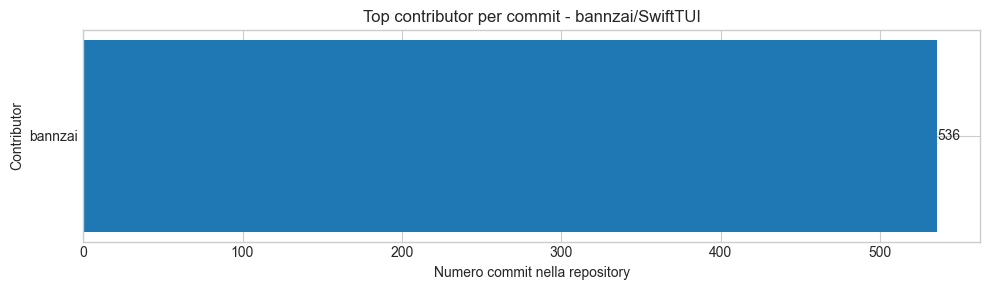

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,735ecbff2ef1105cdc0e26c74e32c83e264b670c,bannzai,2025-07-16T23:09:40Z,1,4,28,32,Fix doc,https://github.com/bannzai/SwiftTUI/compare/1d3c15b9d4c0e2402ecc4b6df74e2100b5e7e9b5...735ecbff2ef1105cdc0e26c74e32c83e264b670c
1,1d3c15b9d4c0e2402ecc4b6df74e2100b5e7e9b5,bannzai,2025-07-16T22:49:26Z,1,30,0,30,docs: コーディングスタイル修正に関する動作確認方法を追記,https://github.com/bannzai/SwiftTUI/compare/fe45e24aea855b72a93f3854cc4c2ed777339eb9...1d3c15b9d4c0e2402ecc4b6df74e2100b5e7e9b5
2,7b0c114d9fe27804fae2b174d3180178ccf6d479,bannzai,2025-07-20T10:27:54Z,1,30,0,30,docs: CLAUDE.mdとREADME.mdにRe-architectureドキュメントへの参照を追加,https://github.com/bannzai/SwiftTUI/compare/63262a8f47a8d9ea9b33ea6e79f62c422f5f14f5...7b0c114d9fe27804fae2b174d3180178ccf6d479
3,aa7a0fa8b24b2b2ee2a2f5366519e5f60e9657ab,bannzai,2025-07-18T11:50:17Z,1,18,0,18,docs: 日本語文字間スペース問題の解決方法とDemoForLT動作確認を追記,https://github.com/bannzai/SwiftTUI/compare/2ca5cbf7f63f0c4ac4b6cd075e5793a820539e79...aa7a0fa8b24b2b2ee2a2f5366519e5f60e9657ab
4,63262a8f47a8d9ea9b33ea6e79f62c422f5f14f5,bannzai,2025-07-19T01:04:50Z,1,16,0,16,docs: テストアプリケーションの動作確認方法を追記,https://github.com/bannzai/SwiftTUI/compare/23b69e486d8f6d85798deab9976434ac08eb25d3...63262a8f47a8d9ea9b33ea6e79f62c422f5f14f5
5,2ca5cbf7f63f0c4ac4b6cd075e5793a820539e79,bannzai,2025-07-18T10:05:51Z,1,13,0,13,docs: READMEとCLAUDE.mdを更新,https://github.com/bannzai/SwiftTUI/compare/01ddf3e00263fe64327f2badceba5dba9460b312...2ca5cbf7f63f0c4ac4b6cd075e5793a820539e79
6,01ddf3e00263fe64327f2badceba5dba9460b312,bannzai,2025-07-18T07:21:06Z,1,10,0,10,docs: 日本語文字幅修正の動作確認方法とCLAUDE.mdを更新,https://github.com/bannzai/SwiftTUI/compare/7c9ac669a2511fd168cc5faf3b0afc14cac02a31...01ddf3e00263fe64327f2badceba5dba9460b312
7,fe45e24aea855b72a93f3854cc4c2ed777339eb9,bannzai,2025-07-16T11:09:57Z,1,6,0,6,docs: C API詳細コメントとガイドドキュメントを追加,https://github.com/bannzai/SwiftTUI/compare/f46c92dc4e29581b9f3d6a60a68f2657762ae598...fe45e24aea855b72a93f3854cc4c2ed777339eb9
8,23b69e486d8f6d85798deab9976434ac08eb25d3,bannzai,2025-07-18T12:12:33Z,1,2,1,3,docs: TextFieldの日本語プレースホルダー修正について記載,https://github.com/bannzai/SwiftTUI/compare/aa7a0fa8b24b2b2ee2a2f5366519e5f60e9657ab...23b69e486d8f6d85798deab9976434ac08eb25d3
9,7c9ac669a2511fd168cc5faf3b0afc14cac02a31,bannzai,2025-07-17T07:41:48Z,1,1,0,1,Add coding-rule,https://github.com/bannzai/SwiftTUI/compare/735ecbff2ef1105cdc0e26c74e32c83e264b670c...7c9ac669a2511fd168cc5faf3b0afc14cac02a31


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,735ecbff2ef1105cdc0e26c74e32c83e264b670c,bannzai,2025-07-16T23:09:40Z,32,4,28,1,Fix doc,https://github.com/bannzai/SwiftTUI/compare/1d3c15b9d4c0e2402ecc4b6df74e2100b5e7e9b5...735ecbff2ef1105cdc0e26c74e32c83e264b670c
1,1d3c15b9d4c0e2402ecc4b6df74e2100b5e7e9b5,bannzai,2025-07-16T22:49:26Z,30,30,0,1,docs: コーディングスタイル修正に関する動作確認方法を追記,https://github.com/bannzai/SwiftTUI/compare/fe45e24aea855b72a93f3854cc4c2ed777339eb9...1d3c15b9d4c0e2402ecc4b6df74e2100b5e7e9b5
2,7b0c114d9fe27804fae2b174d3180178ccf6d479,bannzai,2025-07-20T10:27:54Z,30,30,0,1,docs: CLAUDE.mdとREADME.mdにRe-architectureドキュメントへの参照を追加,https://github.com/bannzai/SwiftTUI/compare/63262a8f47a8d9ea9b33ea6e79f62c422f5f14f5...7b0c114d9fe27804fae2b174d3180178ccf6d479
3,aa7a0fa8b24b2b2ee2a2f5366519e5f60e9657ab,bannzai,2025-07-18T11:50:17Z,18,18,0,1,docs: 日本語文字間スペース問題の解決方法とDemoForLT動作確認を追記,https://github.com/bannzai/SwiftTUI/compare/2ca5cbf7f63f0c4ac4b6cd075e5793a820539e79...aa7a0fa8b24b2b2ee2a2f5366519e5f60e9657ab
4,63262a8f47a8d9ea9b33ea6e79f62c422f5f14f5,bannzai,2025-07-19T01:04:50Z,16,16,0,1,docs: テストアプリケーションの動作確認方法を追記,https://github.com/bannzai/SwiftTUI/compare/23b69e486d8f6d85798deab9976434ac08eb25d3...63262a8f47a8d9ea9b33ea6e79f62c422f5f14f5
5,2ca5cbf7f63f0c4ac4b6cd075e5793a820539e79,bannzai,2025-07-18T10:05:51Z,13,13,0,1,docs: READMEとCLAUDE.mdを更新,https://github.com/bannzai/SwiftTUI/compare/01ddf3e00263fe64327f2badceba5dba9460b312...2ca5cbf7f63f0c4ac4b6cd075e5793a820539e79
6,01ddf3e00263fe64327f2badceba5dba9460b312,bannzai,2025-07-18T07:21:06Z,10,10,0,1,docs: 日本語文字幅修正の動作確認方法とCLAUDE.mdを更新,https://github.com/bannzai/SwiftTUI/compare/7c9ac669a2511fd168cc5faf3b0afc14cac02a31...01ddf3e00263fe64327f2badceba5dba9460b312
7,fe45e24aea855b72a93f3854cc4c2ed777339eb9,bannzai,2025-07-16T11:09:57Z,6,6,0,1,docs: C API詳細コメントとガイドドキュメントを追加,https://github.com/bannzai/SwiftTUI/compare/f46c92dc4e29581b9f3d6a60a68f2657762ae598...fe45e24aea855b72a93f3854cc4c2ed777339eb9
8,23b69e486d8f6d85798deab9976434ac08eb25d3,bannzai,2025-07-18T12:12:33Z,3,2,1,1,docs: TextFieldの日本語プレースホルダー修正について記載,https://github.com/bannzai/SwiftTUI/compare/aa7a0fa8b24b2b2ee2a2f5366519e5f60e9657ab...23b69e486d8f6d85798deab9976434ac08eb25d3
9,7c9ac669a2511fd168cc5faf3b0afc14cac02a31,bannzai,2025-07-17T07:41:48Z,1,1,0,1,Add coding-rule,https://github.com/bannzai/SwiftTUI/compare/735ecbff2ef1105cdc0e26c74e32c83e264b670c...7c9ac669a2511fd168cc5faf3b0afc14cac02a31


In [22]:
show_repo_report("bannzai/SwiftTUI")

## czlonkowski/n8n-mcp

### Contributor nella repository

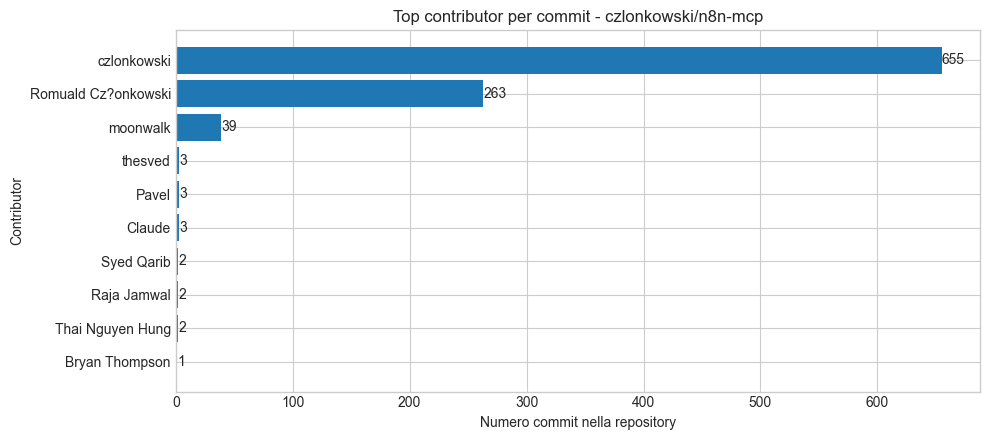

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,6d614267afed8d06530bcd510961eb0b8d054535,czlonkowski,2025-07-30T07:42:17Z,1,115,1,116,docs: update testing documentation to reflect actual implementation,https://github.com/czlonkowski/n8n-mcp/compare/48219fb860a77a9b276091a6dac548ae58f9f3e1...6d614267afed8d06530bcd510961eb0b8d054535
1,05424f66af655c36deeb78e0cfceb5cbc9a9fd7f,Romuald Cz?onkowski,2025-11-24T17:53:26Z,1,34,1,35,feat: Session Persistence API for Zero-Downtime Deployments (v2.24.1) (#438),https://github.com/czlonkowski/n8n-mcp/compare/717d6f927fd863f82b5ecd23b56e01acc6835872...05424f66af655c36deeb78e0cfceb5cbc9a9fd7f
2,796c42731760ddf5d1dc69a1ed001ed32b4b90ab,Romuald Cz?onkowski,2026-04-04T09:27:20Z,1,2,29,31,feat: add n8n_audit_instance and n8n_manage_credentials tools (v2.47.0) (#702),https://github.com/czlonkowski/n8n-mcp/compare/c2dc7c9c51b08a975fa4a54737c79a9634bcbf36...796c42731760ddf5d1dc69a1ed001ed32b4b90ab
3,717d6f927fd863f82b5ecd23b56e01acc6835872,Romuald Cz?onkowski,2025-11-21T15:48:49Z,1,8,0,8,Release v2.23.0: Type Structure Validation (Phases 1-4) (#434),https://github.com/czlonkowski/n8n-mcp/compare/7300957d136cfa009e8a5610d741124a093dea5b...717d6f927fd863f82b5ecd23b56e01acc6835872
4,13c166348945640043cc579bb0ad3fc767e7c219,czlonkowski,2025-08-07T18:05:57Z,1,3,0,3,fix: address critical code review issues for validation improvements,https://github.com/czlonkowski/n8n-mcp/compare/a4053de998595b4321576ad6a908e65590816ee0...13c166348945640043cc579bb0ad3fc767e7c219
5,6699a1d34c8cb93612084659096cc666e612ebdd,czlonkowski,2025-07-30T11:44:35Z,1,3,0,3,test: implement comprehensive testing improvements from PR #104 review,https://github.com/czlonkowski/n8n-mcp/compare/6d614267afed8d06530bcd510961eb0b8d054535...6699a1d34c8cb93612084659096cc666e612ebdd
6,7300957d136cfa009e8a5610d741124a093dea5b,Romuald Cz?onkowski,2025-10-22T08:28:32Z,1,2,1,3,chore: update n8n to v1.116.2 (#348),https://github.com/czlonkowski/n8n-mcp/compare/d49416fc589dcb381a15fd7de46b58a6fe681ad0...7300957d136cfa009e8a5610d741124a093dea5b
7,d49416fc589dcb381a15fd7de46b58a6fe681ad0,czlonkowski,2025-09-14T17:09:18Z,1,2,1,3,docs: update CHANGELOG with fuzzy node type matching feature,https://github.com/czlonkowski/n8n-mcp/compare/13c166348945640043cc579bb0ad3fc767e7c219...d49416fc589dcb381a15fd7de46b58a6fe681ad0
8,c2dc7c9c51b08a975fa4a54737c79a9634bcbf36,Romuald Cz?onkowski,2025-12-05T10:17:51Z,1,1,1,2,feat: configurable MAX_SESSIONS via N8N_MCP_MAX_SESSIONS env var (v2.28.4) (#469),https://github.com/czlonkowski/n8n-mcp/compare/05424f66af655c36deeb78e0cfceb5cbc9a9fd7f...c2dc7c9c51b08a975fa4a54737c79a9634bcbf36
9,a4053de998595b4321576ad6a908e65590816ee0,czlonkowski,2025-07-31T15:58:52Z,1,1,0,1,chore: bump version to 2.8.3 and update changelog,https://github.com/czlonkowski/n8n-mcp/compare/6699a1d34c8cb93612084659096cc666e612ebdd...a4053de998595b4321576ad6a908e65590816ee0


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,6d614267afed8d06530bcd510961eb0b8d054535,czlonkowski,2025-07-30T07:42:17Z,116,115,1,1,docs: update testing documentation to reflect actual implementation,https://github.com/czlonkowski/n8n-mcp/compare/48219fb860a77a9b276091a6dac548ae58f9f3e1...6d614267afed8d06530bcd510961eb0b8d054535
1,05424f66af655c36deeb78e0cfceb5cbc9a9fd7f,Romuald Cz?onkowski,2025-11-24T17:53:26Z,35,34,1,1,feat: Session Persistence API for Zero-Downtime Deployments (v2.24.1) (#438),https://github.com/czlonkowski/n8n-mcp/compare/717d6f927fd863f82b5ecd23b56e01acc6835872...05424f66af655c36deeb78e0cfceb5cbc9a9fd7f
2,796c42731760ddf5d1dc69a1ed001ed32b4b90ab,Romuald Cz?onkowski,2026-04-04T09:27:20Z,31,2,29,1,feat: add n8n_audit_instance and n8n_manage_credentials tools (v2.47.0) (#702),https://github.com/czlonkowski/n8n-mcp/compare/c2dc7c9c51b08a975fa4a54737c79a9634bcbf36...796c42731760ddf5d1dc69a1ed001ed32b4b90ab
3,717d6f927fd863f82b5ecd23b56e01acc6835872,Romuald Cz?onkowski,2025-11-21T15:48:49Z,8,8,0,1,Release v2.23.0: Type Structure Validation (Phases 1-4) (#434),https://github.com/czlonkowski/n8n-mcp/compare/7300957d136cfa009e8a5610d741124a093dea5b...717d6f927fd863f82b5ecd23b56e01acc6835872
4,13c166348945640043cc579bb0ad3fc767e7c219,czlonkowski,2025-08-07T18:05:57Z,3,3,0,1,fix: address critical code review issues for validation improvements,https://github.com/czlonkowski/n8n-mcp/compare/a4053de998595b4321576ad6a908e65590816ee0...13c166348945640043cc579bb0ad3fc767e7c219
5,6699a1d34c8cb93612084659096cc666e612ebdd,czlonkowski,2025-07-30T11:44:35Z,3,3,0,1,test: implement comprehensive testing improvements from PR #104 review,https://github.com/czlonkowski/n8n-mcp/compare/6d614267afed8d06530bcd510961eb0b8d054535...6699a1d34c8cb93612084659096cc666e612ebdd
6,7300957d136cfa009e8a5610d741124a093dea5b,Romuald Cz?onkowski,2025-10-22T08:28:32Z,3,2,1,1,chore: update n8n to v1.116.2 (#348),https://github.com/czlonkowski/n8n-mcp/compare/d49416fc589dcb381a15fd7de46b58a6fe681ad0...7300957d136cfa009e8a5610d741124a093dea5b
7,d49416fc589dcb381a15fd7de46b58a6fe681ad0,czlonkowski,2025-09-14T17:09:18Z,3,2,1,1,docs: update CHANGELOG with fuzzy node type matching feature,https://github.com/czlonkowski/n8n-mcp/compare/13c166348945640043cc579bb0ad3fc767e7c219...d49416fc589dcb381a15fd7de46b58a6fe681ad0
8,c2dc7c9c51b08a975fa4a54737c79a9634bcbf36,Romuald Cz?onkowski,2025-12-05T10:17:51Z,2,1,1,1,feat: configurable MAX_SESSIONS via N8N_MCP_MAX_SESSIONS env var (v2.28.4) (#469),https://github.com/czlonkowski/n8n-mcp/compare/05424f66af655c36deeb78e0cfceb5cbc9a9fd7f...c2dc7c9c51b08a975fa4a54737c79a9634bcbf36
9,a4053de998595b4321576ad6a908e65590816ee0,czlonkowski,2025-07-31T15:58:52Z,1,1,0,1,chore: bump version to 2.8.3 and update changelog,https://github.com/czlonkowski/n8n-mcp/compare/6699a1d34c8cb93612084659096cc666e612ebdd...a4053de998595b4321576ad6a908e65590816ee0


In [9]:
show_repo_report("czlonkowski/n8n-mcp")

## devill/refakts

### Contributor nella repository

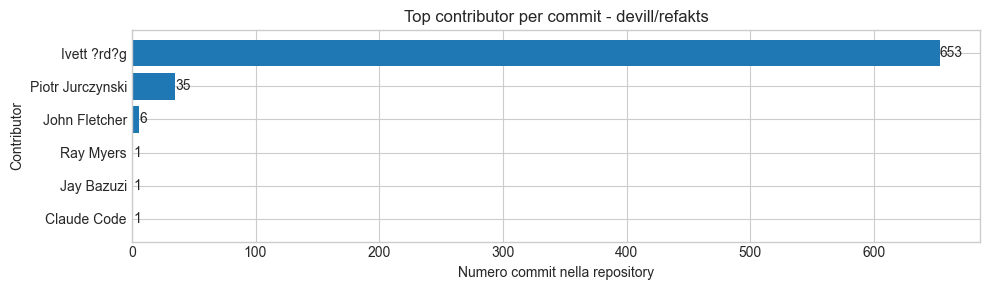

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,a1782a00563c840f68e983c7b67841ff2d48a5e4,Ivett ?rd?g,2025-07-26T15:19:32Z,1,80,304,384,Restructure CLAUDE.md and create specialized documentation guides,https://github.com/devill/refakts/compare/a7a54c1ae877cb854dfea77f970ca7fea7a20a61...a1782a00563c840f68e983c7b67841ff2d48a5e4
1,7d6d7b0ab4c65203082276f925581ca4923c6ade,Ivett ?rd?g,2025-07-25T17:14:07Z,1,30,0,30,Update CLAUDE.md with architecture,https://github.com/devill/refakts/compare/fe05a5ad11029a0a300b6af24851e47c0fa7957d...7d6d7b0ab4c65203082276f925581ca4923c6ade
2,1af751ed2b2cc2491735254407711304130eec95,Ivett ?rd?g,2025-07-26T15:39:27Z,1,17,7,24,Refine CLAUDE.md documentation structure,https://github.com/devill/refakts/compare/a1782a00563c840f68e983c7b67841ff2d48a5e4...1af751ed2b2cc2491735254407711304130eec95
3,e771b3fefd040dd2eb51eacbf4b4c758c00d4c07,Ivett ?rd?g,2025-07-24T13:39:08Z,1,14,0,14,Fix ASTService to properly load tsconfig.json based on file context,https://github.com/devill/refakts/compare/3520759bd48f94b182516fe17d2e3ad463c6c539...e771b3fefd040dd2eb51eacbf4b4c758c00d4c07
4,3e33f72bb58b16df6ba949d921dc5838be08d0da,Ivett ?rd?g,2025-07-26T16:37:13Z,1,7,1,8,Fix help generation bug in documentation,https://github.com/devill/refakts/compare/1af751ed2b2cc2491735254407711304130eec95...3e33f72bb58b16df6ba949d921dc5838be08d0da
5,fe05a5ad11029a0a300b6af24851e47c0fa7957d,Ivett ?rd?g,2025-07-23T08:16:52Z,1,1,7,8,Move CLI files to command-line-parser directory,https://github.com/devill/refakts/compare/e771b3fefd040dd2eb51eacbf4b4c758c00d4c07...fe05a5ad11029a0a300b6af24851e47c0fa7957d
6,79ea77a61b911122bb7134378d624e654acaa1c9,Ivett ?rd?g,2025-07-26T18:35:27Z,1,6,1,7,Fix select command to return relative paths instead of filenames,https://github.com/devill/refakts/compare/3e33f72bb58b16df6ba949d921dc5838be08d0da...79ea77a61b911122bb7134378d624e654acaa1c9
7,afec2a129a3a62ae468f49b10587081b665d85f0,Ivett ?rd?g,2025-07-26T18:44:43Z,1,2,1,3,Add GitHub issue template to replace format removed from CLAUDE.md,https://github.com/devill/refakts/compare/79ea77a61b911122bb7134378d624e654acaa1c9...afec2a129a3a62ae468f49b10587081b665d85f0
8,698675a8d11600a71a4f3c1739e2af64fe2e1aec,Piotr Jurczynski,2025-08-05T22:12:44Z,1,2,0,2,Add reminder to use --help for unfamiliar RefakTS commands,https://github.com/devill/refakts/compare/afec2a129a3a62ae468f49b10587081b665d85f0...698675a8d11600a71a4f3c1739e2af64fe2e1aec
9,a7a54c1ae877cb854dfea77f970ca7fea7a20a61,Ivett ?rd?g,2025-07-25T17:28:13Z,1,1,0,1,Reorganize test file structure and update documentation,https://github.com/devill/refakts/compare/7d6d7b0ab4c65203082276f925581ca4923c6ade...a7a54c1ae877cb854dfea77f970ca7fea7a20a61


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,a1782a00563c840f68e983c7b67841ff2d48a5e4,Ivett ?rd?g,2025-07-26T15:19:32Z,384,80,304,1,Restructure CLAUDE.md and create specialized documentation guides,https://github.com/devill/refakts/compare/a7a54c1ae877cb854dfea77f970ca7fea7a20a61...a1782a00563c840f68e983c7b67841ff2d48a5e4
1,7d6d7b0ab4c65203082276f925581ca4923c6ade,Ivett ?rd?g,2025-07-25T17:14:07Z,30,30,0,1,Update CLAUDE.md with architecture,https://github.com/devill/refakts/compare/fe05a5ad11029a0a300b6af24851e47c0fa7957d...7d6d7b0ab4c65203082276f925581ca4923c6ade
2,1af751ed2b2cc2491735254407711304130eec95,Ivett ?rd?g,2025-07-26T15:39:27Z,24,17,7,1,Refine CLAUDE.md documentation structure,https://github.com/devill/refakts/compare/a1782a00563c840f68e983c7b67841ff2d48a5e4...1af751ed2b2cc2491735254407711304130eec95
3,e771b3fefd040dd2eb51eacbf4b4c758c00d4c07,Ivett ?rd?g,2025-07-24T13:39:08Z,14,14,0,1,Fix ASTService to properly load tsconfig.json based on file context,https://github.com/devill/refakts/compare/3520759bd48f94b182516fe17d2e3ad463c6c539...e771b3fefd040dd2eb51eacbf4b4c758c00d4c07
4,3e33f72bb58b16df6ba949d921dc5838be08d0da,Ivett ?rd?g,2025-07-26T16:37:13Z,8,7,1,1,Fix help generation bug in documentation,https://github.com/devill/refakts/compare/1af751ed2b2cc2491735254407711304130eec95...3e33f72bb58b16df6ba949d921dc5838be08d0da
5,fe05a5ad11029a0a300b6af24851e47c0fa7957d,Ivett ?rd?g,2025-07-23T08:16:52Z,8,1,7,1,Move CLI files to command-line-parser directory,https://github.com/devill/refakts/compare/e771b3fefd040dd2eb51eacbf4b4c758c00d4c07...fe05a5ad11029a0a300b6af24851e47c0fa7957d
6,79ea77a61b911122bb7134378d624e654acaa1c9,Ivett ?rd?g,2025-07-26T18:35:27Z,7,6,1,1,Fix select command to return relative paths instead of filenames,https://github.com/devill/refakts/compare/3e33f72bb58b16df6ba949d921dc5838be08d0da...79ea77a61b911122bb7134378d624e654acaa1c9
7,afec2a129a3a62ae468f49b10587081b665d85f0,Ivett ?rd?g,2025-07-26T18:44:43Z,3,2,1,1,Add GitHub issue template to replace format removed from CLAUDE.md,https://github.com/devill/refakts/compare/79ea77a61b911122bb7134378d624e654acaa1c9...afec2a129a3a62ae468f49b10587081b665d85f0
8,698675a8d11600a71a4f3c1739e2af64fe2e1aec,Piotr Jurczynski,2025-08-05T22:12:44Z,2,2,0,1,Add reminder to use --help for unfamiliar RefakTS commands,https://github.com/devill/refakts/compare/afec2a129a3a62ae468f49b10587081b665d85f0...698675a8d11600a71a4f3c1739e2af64fe2e1aec
9,a7a54c1ae877cb854dfea77f970ca7fea7a20a61,Ivett ?rd?g,2025-07-25T17:28:13Z,1,1,0,1,Reorganize test file structure and update documentation,https://github.com/devill/refakts/compare/7d6d7b0ab4c65203082276f925581ca4923c6ade...a7a54c1ae877cb854dfea77f970ca7fea7a20a61


In [10]:
show_repo_report("devill/refakts")

## docdyhr/mcp-wordpress

### Contributor nella repository

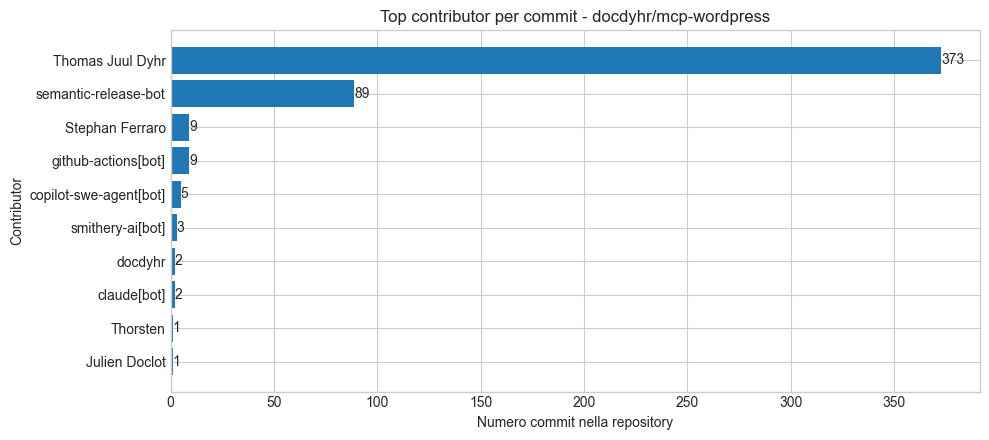

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,8105023b5d04621466bcd9d150a3c45a256d5045,Thomas Juul Dyhr,2025-09-04T11:21:58Z,1,61,1738,1799,feat(architecture): Complete test suite architectural improvements and fixes,https://github.com/docdyhr/mcp-wordpress/compare/12d03fde4984e3609558c2ef29f82f5c6eea8765...8105023b5d04621466bcd9d150a3c45a256d5045
1,90a7ea38699363aa001950dcfc42689a3d139650,Thomas Juul Dyhr,2025-08-28T04:05:54Z,1,808,0,808,feat: release v2.7.0 with composition architecture and complete SEO toolkit,https://github.com/docdyhr/mcp-wordpress/compare/af468690b6578aed6daed7cdd46206df00951684...90a7ea38699363aa001950dcfc42689a3d139650
2,af468690b6578aed6daed7cdd46206df00951684,Thomas Juul Dyhr,2025-08-22T19:02:19Z,1,120,0,120,fix: update security contact information to remove invalid email link,https://github.com/docdyhr/mcp-wordpress/compare/c25087e1e604d325347c5c02e588543385e2eb87...af468690b6578aed6daed7cdd46206df00951684
3,12d03fde4984e3609558c2ef29f82f5c6eea8765,Thomas Juul Dyhr,2025-08-31T16:12:46Z,1,35,2,37,feat(version): Implement best-practices versioning system with SemVer support,https://github.com/docdyhr/mcp-wordpress/compare/90a7ea38699363aa001950dcfc42689a3d139650...12d03fde4984e3609558c2ef29f82f5c6eea8765
4,24197a33c4eaf373460f9a2457bd6c0eb77dd946,Thomas Juul Dyhr,2025-09-23T21:21:48Z,1,21,15,36,fix(ci): Add missing test:security:validation script and fix formatting,https://github.com/docdyhr/mcp-wordpress/compare/0ae8c44d2c6f8bd4822bcf49f34155ee1dd5d787...24197a33c4eaf373460f9a2457bd6c0eb77dd946
5,e2100ca313f93d5cb433d8b70958bec1fda53b62,Thomas Juul Dyhr,2026-03-15T20:49:29Z,1,9,5,14,fix: comprehensive project audit improvements (#167),https://github.com/docdyhr/mcp-wordpress/compare/42fd6a88301b7ab7e0cae8310d743cc0c7b5ae16...e2100ca313f93d5cb433d8b70958bec1fda53b62
6,0ae8c44d2c6f8bd4822bcf49f34155ee1dd5d787,Thomas Juul Dyhr,2025-09-04T11:46:09Z,1,10,2,12,feat(ci): Comprehensive CI/CD pipeline health improvements,https://github.com/docdyhr/mcp-wordpress/compare/8105023b5d04621466bcd9d150a3c45a256d5045...0ae8c44d2c6f8bd4822bcf49f34155ee1dd5d787
7,c25087e1e604d325347c5c02e588543385e2eb87,Thomas Juul Dyhr,2025-08-21T01:15:07Z,1,6,6,12,Fix/ci performance test vitest docs (#98),https://github.com/docdyhr/mcp-wordpress/compare/4489c1475edebfd277172b6801a0c03b65eb3a25...c25087e1e604d325347c5c02e588543385e2eb87
8,42fd6a88301b7ab7e0cae8310d743cc0c7b5ae16,Thomas Juul Dyhr,2025-10-19T16:04:54Z,1,2,2,4,refactor(tests): Remove all skipped tests and update documentation,https://github.com/docdyhr/mcp-wordpress/compare/24197a33c4eaf373460f9a2457bd6c0eb77dd946...42fd6a88301b7ab7e0cae8310d743cc0c7b5ae16
9,35d331ff7d9bb81f919e22ebc25bc9bfa8453fe8,Thomas Juul Dyhr,2026-03-31T19:27:31Z,1,1,1,2,chore: update CLAUDE.md version reference to v3.1.15,https://github.com/docdyhr/mcp-wordpress/compare/e2100ca313f93d5cb433d8b70958bec1fda53b62...35d331ff7d9bb81f919e22ebc25bc9bfa8453fe8


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,8105023b5d04621466bcd9d150a3c45a256d5045,Thomas Juul Dyhr,2025-09-04T11:21:58Z,1799,61,1738,1,feat(architecture): Complete test suite architectural improvements and fixes,https://github.com/docdyhr/mcp-wordpress/compare/12d03fde4984e3609558c2ef29f82f5c6eea8765...8105023b5d04621466bcd9d150a3c45a256d5045
1,90a7ea38699363aa001950dcfc42689a3d139650,Thomas Juul Dyhr,2025-08-28T04:05:54Z,808,808,0,1,feat: release v2.7.0 with composition architecture and complete SEO toolkit,https://github.com/docdyhr/mcp-wordpress/compare/af468690b6578aed6daed7cdd46206df00951684...90a7ea38699363aa001950dcfc42689a3d139650
2,af468690b6578aed6daed7cdd46206df00951684,Thomas Juul Dyhr,2025-08-22T19:02:19Z,120,120,0,1,fix: update security contact information to remove invalid email link,https://github.com/docdyhr/mcp-wordpress/compare/c25087e1e604d325347c5c02e588543385e2eb87...af468690b6578aed6daed7cdd46206df00951684
3,12d03fde4984e3609558c2ef29f82f5c6eea8765,Thomas Juul Dyhr,2025-08-31T16:12:46Z,37,35,2,1,feat(version): Implement best-practices versioning system with SemVer support,https://github.com/docdyhr/mcp-wordpress/compare/90a7ea38699363aa001950dcfc42689a3d139650...12d03fde4984e3609558c2ef29f82f5c6eea8765
4,24197a33c4eaf373460f9a2457bd6c0eb77dd946,Thomas Juul Dyhr,2025-09-23T21:21:48Z,36,21,15,1,fix(ci): Add missing test:security:validation script and fix formatting,https://github.com/docdyhr/mcp-wordpress/compare/0ae8c44d2c6f8bd4822bcf49f34155ee1dd5d787...24197a33c4eaf373460f9a2457bd6c0eb77dd946
5,e2100ca313f93d5cb433d8b70958bec1fda53b62,Thomas Juul Dyhr,2026-03-15T20:49:29Z,14,9,5,1,fix: comprehensive project audit improvements (#167),https://github.com/docdyhr/mcp-wordpress/compare/42fd6a88301b7ab7e0cae8310d743cc0c7b5ae16...e2100ca313f93d5cb433d8b70958bec1fda53b62
6,0ae8c44d2c6f8bd4822bcf49f34155ee1dd5d787,Thomas Juul Dyhr,2025-09-04T11:46:09Z,12,10,2,1,feat(ci): Comprehensive CI/CD pipeline health improvements,https://github.com/docdyhr/mcp-wordpress/compare/8105023b5d04621466bcd9d150a3c45a256d5045...0ae8c44d2c6f8bd4822bcf49f34155ee1dd5d787
7,c25087e1e604d325347c5c02e588543385e2eb87,Thomas Juul Dyhr,2025-08-21T01:15:07Z,12,6,6,1,Fix/ci performance test vitest docs (#98),https://github.com/docdyhr/mcp-wordpress/compare/4489c1475edebfd277172b6801a0c03b65eb3a25...c25087e1e604d325347c5c02e588543385e2eb87
8,42fd6a88301b7ab7e0cae8310d743cc0c7b5ae16,Thomas Juul Dyhr,2025-10-19T16:04:54Z,4,2,2,1,refactor(tests): Remove all skipped tests and update documentation,https://github.com/docdyhr/mcp-wordpress/compare/24197a33c4eaf373460f9a2457bd6c0eb77dd946...42fd6a88301b7ab7e0cae8310d743cc0c7b5ae16
9,35d331ff7d9bb81f919e22ebc25bc9bfa8453fe8,Thomas Juul Dyhr,2026-03-31T19:27:31Z,2,1,1,1,chore: update CLAUDE.md version reference to v3.1.15,https://github.com/docdyhr/mcp-wordpress/compare/e2100ca313f93d5cb433d8b70958bec1fda53b62...35d331ff7d9bb81f919e22ebc25bc9bfa8453fe8


In [11]:
show_repo_report("docdyhr/mcp-wordpress")

## evmts/guillotine

### Contributor nella repository

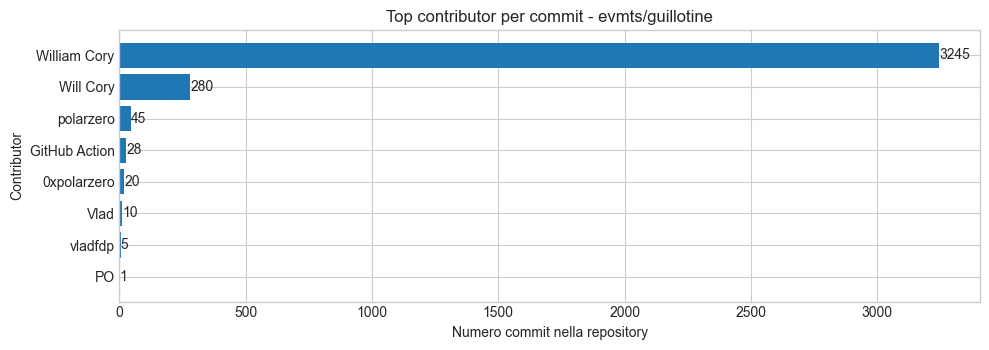

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,03912a6a1ff82ee95d122fbe96c2e70189181173,William Cory,2025-12-21T00:55:50Z,1,34,0,34,fix(frame): Decouple Frame from DefaultEvm type (#852),https://github.com/evmts/guillotine/compare/293757dcc93ee13ab261588d976cafb533cdc35f...03912a6a1ff82ee95d122fbe96c2e70189181173
1,27c9348e412b649bda92476623d0d12136ecd761,William Cory,2025-09-14T21:55:02Z,1,33,0,33,? docs: Fix ArrayList API documentation for Zig 0.15.1,https://github.com/evmts/guillotine/compare/855e72f7b93a2ebfee6370bb59af34cf89df012c...27c9348e412b649bda92476623d0d12136ecd761
2,bb93ed6a3f5f305288e4628f4f8dff81c5fcf5ba,William Cory,2025-09-27T17:33:43Z,1,27,5,32,? docs: Update documentation for new test structure,https://github.com/evmts/guillotine/compare/5a71b699aac627d90631be0214528f88dafdf5d5...bb93ed6a3f5f305288e4628f4f8dff81c5fcf5ba
3,f2f3e47150be07477321dcb8760400c1de06d543,William Cory,2025-09-24T02:43:06Z,1,29,2,31,? docs: Update project documentation,https://github.com/evmts/guillotine/compare/4f280f6e50652acb0fa547b3bf8a57a1b76f522a...f2f3e47150be07477321dcb8760400c1de06d543
4,293757dcc93ee13ab261588d976cafb533cdc35f,William Cory,2025-12-20T21:59:24Z,1,16,0,16,? docs: Add documentation navigation to main project file,https://github.com/evmts/guillotine/compare/a89452545c01eac22bbf3504d1446acac1ba1904...293757dcc93ee13ab261588d976cafb533cdc35f
5,987175a6ee84cc28030c7ca8ce1636debe4957dc,William Cory,2025-09-16T04:04:46Z,1,8,0,8,? docs: Clarify placeholder ban and error handling requirements,https://github.com/evmts/guillotine/compare/44c1d17bd8a833476fe61e73ae4ee46ed97466e1...987175a6ee84cc28030c7ca8ce1636debe4957dc
6,44c1d17bd8a833476fe61e73ae4ee46ed97466e1,William Cory,2025-09-14T23:54:06Z,1,3,0,3,:recycle: chore: Refactor EVM via human,https://github.com/evmts/guillotine/compare/27c9348e412b649bda92476623d0d12136ecd761...44c1d17bd8a833476fe61e73ae4ee46ed97466e1
7,4f280f6e50652acb0fa547b3bf8a57a1b76f522a,William Cory,2025-09-16T05:42:21Z,1,1,1,2,? docs: Update documentation and add TypeScript EVM issues,https://github.com/evmts/guillotine/compare/987175a6ee84cc28030c7ca8ce1636debe4957dc...4f280f6e50652acb0fa547b3bf8a57a1b76f522a
8,5a71b699aac627d90631be0214528f88dafdf5d5,William Cory,2025-09-26T19:16:45Z,1,1,0,1,? docs: Add critical crash handling security guidelines,https://github.com/evmts/guillotine/compare/f2f3e47150be07477321dcb8760400c1de06d543...5a71b699aac627d90631be0214528f88dafdf5d5
9,a89452545c01eac22bbf3504d1446acac1ba1904,William Cory,2025-10-25T18:49:29Z,1,0,1,1,? docs: Update documentation for new project structure,https://github.com/evmts/guillotine/compare/bb93ed6a3f5f305288e4628f4f8dff81c5fcf5ba...a89452545c01eac22bbf3504d1446acac1ba1904


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,03912a6a1ff82ee95d122fbe96c2e70189181173,William Cory,2025-12-21T00:55:50Z,34,34,0,1,fix(frame): Decouple Frame from DefaultEvm type (#852),https://github.com/evmts/guillotine/compare/293757dcc93ee13ab261588d976cafb533cdc35f...03912a6a1ff82ee95d122fbe96c2e70189181173
1,27c9348e412b649bda92476623d0d12136ecd761,William Cory,2025-09-14T21:55:02Z,33,33,0,1,? docs: Fix ArrayList API documentation for Zig 0.15.1,https://github.com/evmts/guillotine/compare/855e72f7b93a2ebfee6370bb59af34cf89df012c...27c9348e412b649bda92476623d0d12136ecd761
2,bb93ed6a3f5f305288e4628f4f8dff81c5fcf5ba,William Cory,2025-09-27T17:33:43Z,32,27,5,1,? docs: Update documentation for new test structure,https://github.com/evmts/guillotine/compare/5a71b699aac627d90631be0214528f88dafdf5d5...bb93ed6a3f5f305288e4628f4f8dff81c5fcf5ba
3,f2f3e47150be07477321dcb8760400c1de06d543,William Cory,2025-09-24T02:43:06Z,31,29,2,1,? docs: Update project documentation,https://github.com/evmts/guillotine/compare/4f280f6e50652acb0fa547b3bf8a57a1b76f522a...f2f3e47150be07477321dcb8760400c1de06d543
4,293757dcc93ee13ab261588d976cafb533cdc35f,William Cory,2025-12-20T21:59:24Z,16,16,0,1,? docs: Add documentation navigation to main project file,https://github.com/evmts/guillotine/compare/a89452545c01eac22bbf3504d1446acac1ba1904...293757dcc93ee13ab261588d976cafb533cdc35f
5,987175a6ee84cc28030c7ca8ce1636debe4957dc,William Cory,2025-09-16T04:04:46Z,8,8,0,1,? docs: Clarify placeholder ban and error handling requirements,https://github.com/evmts/guillotine/compare/44c1d17bd8a833476fe61e73ae4ee46ed97466e1...987175a6ee84cc28030c7ca8ce1636debe4957dc
6,44c1d17bd8a833476fe61e73ae4ee46ed97466e1,William Cory,2025-09-14T23:54:06Z,3,3,0,1,:recycle: chore: Refactor EVM via human,https://github.com/evmts/guillotine/compare/27c9348e412b649bda92476623d0d12136ecd761...44c1d17bd8a833476fe61e73ae4ee46ed97466e1
7,4f280f6e50652acb0fa547b3bf8a57a1b76f522a,William Cory,2025-09-16T05:42:21Z,2,1,1,1,? docs: Update documentation and add TypeScript EVM issues,https://github.com/evmts/guillotine/compare/987175a6ee84cc28030c7ca8ce1636debe4957dc...4f280f6e50652acb0fa547b3bf8a57a1b76f522a
8,5a71b699aac627d90631be0214528f88dafdf5d5,William Cory,2025-09-26T19:16:45Z,1,1,0,1,? docs: Add critical crash handling security guidelines,https://github.com/evmts/guillotine/compare/f2f3e47150be07477321dcb8760400c1de06d543...5a71b699aac627d90631be0214528f88dafdf5d5
9,a89452545c01eac22bbf3504d1446acac1ba1904,William Cory,2025-10-25T18:49:29Z,1,0,1,1,? docs: Update documentation for new project structure,https://github.com/evmts/guillotine/compare/bb93ed6a3f5f305288e4628f4f8dff81c5fcf5ba...a89452545c01eac22bbf3504d1446acac1ba1904


In [12]:
show_repo_report("evmts/guillotine")

## julep-ai/steadytext

### Contributor nella repository

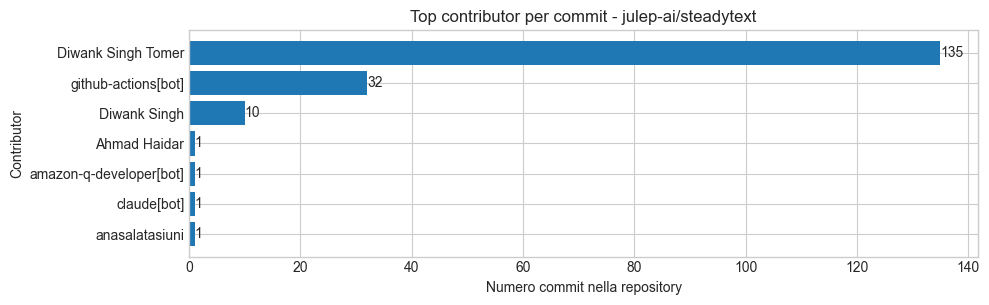

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,6ab81d81515c2c2fb4f01cd28124ed179c5096fb,Diwank Singh Tomer,2025-09-07T14:59:57Z,1,123,487,610,feat: Add comprehensive Prompt Registry feature for PostgreSQL extension (#105),https://github.com/julep-ai/steadytext/compare/b7251ea3400a2f68c02a6beeac7d06c5557971bf...6ab81d81515c2c2fb4f01cd28124ed179c5096fb
1,4e6939b7453d977684c295840026dc076b08b64d,Diwank Singh Tomer,2025-08-27T07:27:08Z,1,139,8,147,fix: fix pg ext & update version to 2025.8.26 (#103),https://github.com/julep-ai/steadytext/compare/e85ff78aa0a17acc5508325f19d961e4632aa962...4e6939b7453d977684c295840026dc076b08b64d
2,52e591d9388488ee64e3713a5625a4ccbacedfb8,Diwank Singh Tomer,2025-11-27T07:26:17Z,1,85,4,89,fix: Simplify pg_steadytext and fix the max character limit (#110),https://github.com/julep-ai/steadytext/compare/128ce60c8fdea1c0522ced4551831bb7aca95381...52e591d9388488ee64e3713a5625a4ccbacedfb8
3,97873a6aa6bef2ad662a8f4484ebe648b1bb704e,Diwank Singh Tomer,2025-08-27T10:30:13Z,1,27,3,30,feat: Enhance DevContainer workflow and CI/CD documentation (#104),https://github.com/julep-ai/steadytext/compare/4e6939b7453d977684c295840026dc076b08b64d...97873a6aa6bef2ad662a8f4484ebe648b1bb704e
4,b7251ea3400a2f68c02a6beeac7d06c5557971bf,Diwank Singh,2025-08-27T10:47:58Z,1,20,1,21,docs: add AIDEV-NOTE comments and GitHub release process documentation,https://github.com/julep-ai/steadytext/compare/6b3b5041769d1e22c9ea501c36847d4246ba1e75...b7251ea3400a2f68c02a6beeac7d06c5557971bf
5,f735e3a1e984204e3498cfe5d5dc93c34ebb030e,Diwank Singh Tomer,2025-08-16T12:45:02Z,1,17,3,20,fix: add schema qualification to table references in pg_steadytext functions (#100),https://github.com/julep-ai/steadytext/compare/470af0f7f1680bfda8e069ff8f7ff973052c4fe1...f735e3a1e984204e3498cfe5d5dc93c34ebb030e
6,e85ff78aa0a17acc5508325f19d961e4632aa962,Diwank Singh Tomer,2025-08-27T07:17:33Z,1,13,1,14,feat: GPT-5 support and custom options (#102),https://github.com/julep-ai/steadytext/compare/f735e3a1e984204e3498cfe5d5dc93c34ebb030e...e85ff78aa0a17acc5508325f19d961e4632aa962
7,128ce60c8fdea1c0522ced4551831bb7aca95381,Diwank Singh Tomer,2025-10-31T14:18:05Z,1,5,0,5,Add remote embedding env override helper and tests (#108),https://github.com/julep-ai/steadytext/compare/2a483c6b15f8210651d7edc3691a9a750ae93cc6...128ce60c8fdea1c0522ced4551831bb7aca95381
8,6b3b5041769d1e22c9ea501c36847d4246ba1e75,Diwank Singh,2025-08-27T10:41:40Z,1,4,0,4,fix: prevent local embedding model loading for remote embeddings,https://github.com/julep-ai/steadytext/compare/97873a6aa6bef2ad662a8f4484ebe648b1bb704e...6b3b5041769d1e22c9ea501c36847d4246ba1e75
9,2a483c6b15f8210651d7edc3691a9a750ae93cc6,Diwank Singh Tomer,2025-09-21T07:14:14Z,1,2,1,3,feat(openrouter): add OpenRouterProvider (generation-only) with streaming fallback (#107),https://github.com/julep-ai/steadytext/compare/6ab81d81515c2c2fb4f01cd28124ed179c5096fb...2a483c6b15f8210651d7edc3691a9a750ae93cc6


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,6ab81d81515c2c2fb4f01cd28124ed179c5096fb,Diwank Singh Tomer,2025-09-07T14:59:57Z,610,123,487,1,feat: Add comprehensive Prompt Registry feature for PostgreSQL extension (#105),https://github.com/julep-ai/steadytext/compare/b7251ea3400a2f68c02a6beeac7d06c5557971bf...6ab81d81515c2c2fb4f01cd28124ed179c5096fb
1,4e6939b7453d977684c295840026dc076b08b64d,Diwank Singh Tomer,2025-08-27T07:27:08Z,147,139,8,1,fix: fix pg ext & update version to 2025.8.26 (#103),https://github.com/julep-ai/steadytext/compare/e85ff78aa0a17acc5508325f19d961e4632aa962...4e6939b7453d977684c295840026dc076b08b64d
2,52e591d9388488ee64e3713a5625a4ccbacedfb8,Diwank Singh Tomer,2025-11-27T07:26:17Z,89,85,4,1,fix: Simplify pg_steadytext and fix the max character limit (#110),https://github.com/julep-ai/steadytext/compare/128ce60c8fdea1c0522ced4551831bb7aca95381...52e591d9388488ee64e3713a5625a4ccbacedfb8
3,97873a6aa6bef2ad662a8f4484ebe648b1bb704e,Diwank Singh Tomer,2025-08-27T10:30:13Z,30,27,3,1,feat: Enhance DevContainer workflow and CI/CD documentation (#104),https://github.com/julep-ai/steadytext/compare/4e6939b7453d977684c295840026dc076b08b64d...97873a6aa6bef2ad662a8f4484ebe648b1bb704e
4,b7251ea3400a2f68c02a6beeac7d06c5557971bf,Diwank Singh,2025-08-27T10:47:58Z,21,20,1,1,docs: add AIDEV-NOTE comments and GitHub release process documentation,https://github.com/julep-ai/steadytext/compare/6b3b5041769d1e22c9ea501c36847d4246ba1e75...b7251ea3400a2f68c02a6beeac7d06c5557971bf
5,f735e3a1e984204e3498cfe5d5dc93c34ebb030e,Diwank Singh Tomer,2025-08-16T12:45:02Z,20,17,3,1,fix: add schema qualification to table references in pg_steadytext functions (#100),https://github.com/julep-ai/steadytext/compare/470af0f7f1680bfda8e069ff8f7ff973052c4fe1...f735e3a1e984204e3498cfe5d5dc93c34ebb030e
6,e85ff78aa0a17acc5508325f19d961e4632aa962,Diwank Singh Tomer,2025-08-27T07:17:33Z,14,13,1,1,feat: GPT-5 support and custom options (#102),https://github.com/julep-ai/steadytext/compare/f735e3a1e984204e3498cfe5d5dc93c34ebb030e...e85ff78aa0a17acc5508325f19d961e4632aa962
7,128ce60c8fdea1c0522ced4551831bb7aca95381,Diwank Singh Tomer,2025-10-31T14:18:05Z,5,5,0,1,Add remote embedding env override helper and tests (#108),https://github.com/julep-ai/steadytext/compare/2a483c6b15f8210651d7edc3691a9a750ae93cc6...128ce60c8fdea1c0522ced4551831bb7aca95381
8,6b3b5041769d1e22c9ea501c36847d4246ba1e75,Diwank Singh,2025-08-27T10:41:40Z,4,4,0,1,fix: prevent local embedding model loading for remote embeddings,https://github.com/julep-ai/steadytext/compare/97873a6aa6bef2ad662a8f4484ebe648b1bb704e...6b3b5041769d1e22c9ea501c36847d4246ba1e75
9,2a483c6b15f8210651d7edc3691a9a750ae93cc6,Diwank Singh Tomer,2025-09-21T07:14:14Z,3,2,1,1,feat(openrouter): add OpenRouterProvider (generation-only) with streaming fallback (#107),https://github.com/julep-ai/steadytext/compare/6ab81d81515c2c2fb4f01cd28124ed179c5096fb...2a483c6b15f8210651d7edc3691a9a750ae93cc6


In [13]:
show_repo_report("julep-ai/steadytext")

## kesslerio/attio-mcp-server

### Contributor nella repository

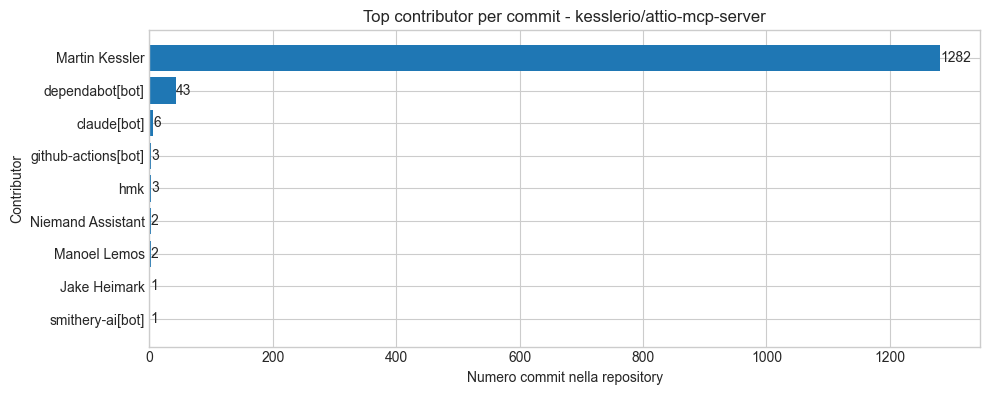

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,952b749e07e30cca149d6b59c5ce101ffab5f45b,Martin Kessler,2026-01-06T02:35:00Z,1,52,30,82,Chore: Migrate from npm to bun package manager (#1094),https://github.com/kesslerio/attio-mcp-server/compare/f93d3c67356f6bc94906ce6572baf45be626edaa...952b749e07e30cca149d6b59c5ce101ffab5f45b
1,b1285460b637dda62bdda07abc045b643a1d73e8,Martin Kessler,2026-02-13T23:36:52Z,1,14,0,14,docs(github): tighten issue and pr hygiene (#1121),https://github.com/kesslerio/attio-mcp-server/compare/952b749e07e30cca149d6b59c5ce101ffab5f45b...b1285460b637dda62bdda07abc045b643a1d73e8
2,a6775f4831b59ef881f17fef1aff5d2beca4f112,Martin Kessler,2025-10-01T23:21:40Z,1,10,1,11,Fix: UX improvements for error messages and person attributes #798 (#804),https://github.com/kesslerio/attio-mcp-server/compare/b564e5a53fefc381c761befc37bd831c9caec449...a6775f4831b59ef881f17fef1aff5d2beca4f112
3,a0e8b9efb7d7ec5e682b77c6fc72b2d24297abd4,Martin Kessler,2025-12-10T17:34:09Z,1,10,0,10,Fix: UX improvements for attribute options tool #980 (#981),https://github.com/kesslerio/attio-mcp-server/compare/fb9c80a9cee503d877d0f6e7ac3498ace47c9762...a0e8b9efb7d7ec5e682b77c6fc72b2d24297abd4
4,709316f7fd732f63591e060ef2bbee220ab75273,Martin Kessler,2025-09-27T22:30:55Z,1,4,1,5,Fix: Honor Smithery API key and type safety improvements,https://github.com/kesslerio/attio-mcp-server/compare/99f3589fcef3c4eeecfe60d6a88a732ae6e9c58d...709316f7fd732f63591e060ef2bbee220ab75273
5,276cc6d7c153f3ab379023bb558a3658868f4e66,Martin Kessler,2025-10-01T21:10:20Z,1,2,1,3,Fix: Enhanced workflow response capture with multi-format NDJSON parsing #798 (#801),https://github.com/kesslerio/attio-mcp-server/compare/709316f7fd732f63591e060ef2bbee220ab75273...276cc6d7c153f3ab379023bb558a3658868f4e66
6,99f3589fcef3c4eeecfe60d6a88a732ae6e9c58d,Martin Kessler,2025-09-27T17:07:53Z,1,2,0,2,Fix: Prototype pollution vulnerability in config-loader.ts #751 (#756),https://github.com/kesslerio/attio-mcp-server/compare/b8e2e6c4ecdfd959d50498c11a90c8a1f215757a...99f3589fcef3c4eeecfe60d6a88a732ae6e9c58d
7,f93d3c67356f6bc94906ce6572baf45be626edaa,Martin Kessler,2025-12-12T18:59:30Z,1,1,1,2,Refactor: Consolidate metadata fetching + Modularize UniversalUpdateService #984 (#1006),https://github.com/kesslerio/attio-mcp-server/compare/a0e8b9efb7d7ec5e682b77c6fc72b2d24297abd4...f93d3c67356f6bc94906ce6572baf45be626edaa
8,b564e5a53fefc381c761befc37bd831c9caec449,Martin Kessler,2025-10-01T21:34:44Z,1,1,0,1,Refactor: Normalize universal note operations (#800),https://github.com/kesslerio/attio-mcp-server/compare/276cc6d7c153f3ab379023bb558a3658868f4e66...b564e5a53fefc381c761befc37bd831c9caec449
9,fb9c80a9cee503d877d0f6e7ac3498ace47c9762,Martin Kessler,2025-12-04T19:37:28Z,1,1,0,1,"Fix: Extract only final Claude response, not intermediate tool chatter (#965)",https://github.com/kesslerio/attio-mcp-server/compare/a6775f4831b59ef881f17fef1aff5d2beca4f112...fb9c80a9cee503d877d0f6e7ac3498ace47c9762


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,952b749e07e30cca149d6b59c5ce101ffab5f45b,Martin Kessler,2026-01-06T02:35:00Z,82,52,30,1,Chore: Migrate from npm to bun package manager (#1094),https://github.com/kesslerio/attio-mcp-server/compare/f93d3c67356f6bc94906ce6572baf45be626edaa...952b749e07e30cca149d6b59c5ce101ffab5f45b
1,b1285460b637dda62bdda07abc045b643a1d73e8,Martin Kessler,2026-02-13T23:36:52Z,14,14,0,1,docs(github): tighten issue and pr hygiene (#1121),https://github.com/kesslerio/attio-mcp-server/compare/952b749e07e30cca149d6b59c5ce101ffab5f45b...b1285460b637dda62bdda07abc045b643a1d73e8
2,a6775f4831b59ef881f17fef1aff5d2beca4f112,Martin Kessler,2025-10-01T23:21:40Z,11,10,1,1,Fix: UX improvements for error messages and person attributes #798 (#804),https://github.com/kesslerio/attio-mcp-server/compare/b564e5a53fefc381c761befc37bd831c9caec449...a6775f4831b59ef881f17fef1aff5d2beca4f112
3,a0e8b9efb7d7ec5e682b77c6fc72b2d24297abd4,Martin Kessler,2025-12-10T17:34:09Z,10,10,0,1,Fix: UX improvements for attribute options tool #980 (#981),https://github.com/kesslerio/attio-mcp-server/compare/fb9c80a9cee503d877d0f6e7ac3498ace47c9762...a0e8b9efb7d7ec5e682b77c6fc72b2d24297abd4
4,709316f7fd732f63591e060ef2bbee220ab75273,Martin Kessler,2025-09-27T22:30:55Z,5,4,1,1,Fix: Honor Smithery API key and type safety improvements,https://github.com/kesslerio/attio-mcp-server/compare/99f3589fcef3c4eeecfe60d6a88a732ae6e9c58d...709316f7fd732f63591e060ef2bbee220ab75273
5,276cc6d7c153f3ab379023bb558a3658868f4e66,Martin Kessler,2025-10-01T21:10:20Z,3,2,1,1,Fix: Enhanced workflow response capture with multi-format NDJSON parsing #798 (#801),https://github.com/kesslerio/attio-mcp-server/compare/709316f7fd732f63591e060ef2bbee220ab75273...276cc6d7c153f3ab379023bb558a3658868f4e66
6,99f3589fcef3c4eeecfe60d6a88a732ae6e9c58d,Martin Kessler,2025-09-27T17:07:53Z,2,2,0,1,Fix: Prototype pollution vulnerability in config-loader.ts #751 (#756),https://github.com/kesslerio/attio-mcp-server/compare/b8e2e6c4ecdfd959d50498c11a90c8a1f215757a...99f3589fcef3c4eeecfe60d6a88a732ae6e9c58d
7,f93d3c67356f6bc94906ce6572baf45be626edaa,Martin Kessler,2025-12-12T18:59:30Z,2,1,1,1,Refactor: Consolidate metadata fetching + Modularize UniversalUpdateService #984 (#1006),https://github.com/kesslerio/attio-mcp-server/compare/a0e8b9efb7d7ec5e682b77c6fc72b2d24297abd4...f93d3c67356f6bc94906ce6572baf45be626edaa
8,b564e5a53fefc381c761befc37bd831c9caec449,Martin Kessler,2025-10-01T21:34:44Z,1,1,0,1,Refactor: Normalize universal note operations (#800),https://github.com/kesslerio/attio-mcp-server/compare/276cc6d7c153f3ab379023bb558a3658868f4e66...b564e5a53fefc381c761befc37bd831c9caec449
9,fb9c80a9cee503d877d0f6e7ac3498ace47c9762,Martin Kessler,2025-12-04T19:37:28Z,1,1,0,1,"Fix: Extract only final Claude response, not intermediate tool chatter (#965)",https://github.com/kesslerio/attio-mcp-server/compare/a6775f4831b59ef881f17fef1aff5d2beca4f112...fb9c80a9cee503d877d0f6e7ac3498ace47c9762


In [14]:
show_repo_report("kesslerio/attio-mcp-server")

## lbds137/tzurot

### Contributor nella repository

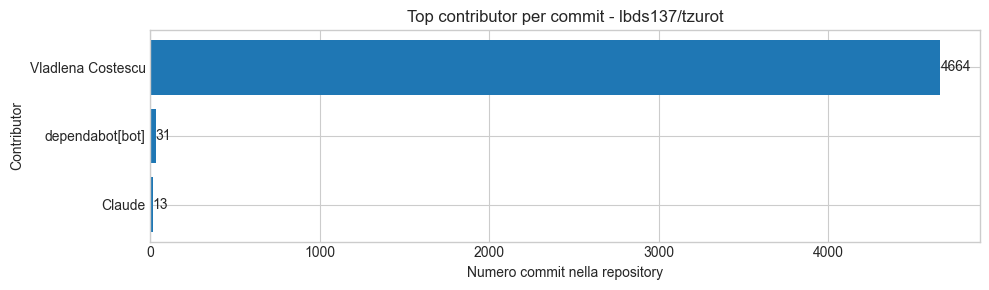

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,b8b4c494d7bd7db3e10770523c9d24b39639d33c,Vladlena Costescu,2026-02-02T02:34:03Z,1,87,536,623,chore: optimize Claude Code configuration for reduced context,https://github.com/lbds137/tzurot/compare/ea7465710eaae044eeda26b0ec140617bf5e5a29...b8b4c494d7bd7db3e10770523c9d24b39639d33c
1,147396fc2149065155abe17fd6e278bd3ba23bac,Vladlena Costescu,2026-02-04T03:49:22Z,1,29,83,112,refactor: move LlmConfigResolver to common-types and update imports,https://github.com/lbds137/tzurot/compare/b8b4c494d7bd7db3e10770523c9d24b39639d33c...147396fc2149065155abe17fd6e278bd3ba23bac
2,a0763df56773205cb40eba099356f4408d1fb371,Vladlena Costescu,2026-02-05T00:01:39Z,1,32,73,105,refactor: migrate skills to rules for reliable auto-loading,https://github.com/lbds137/tzurot/compare/147396fc2149065155abe17fd6e278bd3ba23bac...a0763df56773205cb40eba099356f4408d1fb371
3,f9f9d273b759e756da14c6bfcefff408a5a32e9a,Vladlena Costescu,2026-03-09T10:18:18Z,1,9,7,16,docs: add long-lived branch protection rules,https://github.com/lbds137/tzurot/compare/3107dd9270b53e93792e13bc98a02b4b8d9808de...f9f9d273b759e756da14c6bfcefff408a5a32e9a
4,ea7465710eaae044eeda26b0ec140617bf5e5a29,Vladlena Costescu,2026-02-01T18:19:16Z,1,14,0,14,feat: add static analysis tooling for code quality,https://github.com/lbds137/tzurot/compare/2c765a91fca4022cbef724919961b2cb26c84322...ea7465710eaae044eeda26b0ec140617bf5e5a29
5,cd9b6a02fd679a2895b1966c18746aff6c7fb839,Claude,2026-03-16T04:57:53Z,1,7,2,9,docs: audit and refresh documentation across project,https://github.com/lbds137/tzurot/compare/f9f9d273b759e756da14c6bfcefff408a5a32e9a...cd9b6a02fd679a2895b1966c18746aff6c7fb839
6,232a6654b80dfee8daa3f07bccf800bb34df383b,Vladlena Costescu,2026-02-07T17:10:39Z,1,3,1,4,"docs: add documentation governance rule, expand audit skill, fix stale refs",https://github.com/lbds137/tzurot/compare/a0763df56773205cb40eba099356f4408d1fb371...232a6654b80dfee8daa3f07bccf800bb34df383b
7,94681b79b6d78e61e8f4813df26bdf5b46873877,Vladlena Costescu,2026-02-10T03:25:21Z,1,2,1,3,fix(bot-client): escape backslashes in memory inspector table; document integration tests,https://github.com/lbds137/tzurot/compare/232a6654b80dfee8daa3f07bccf800bb34df383b...94681b79b6d78e61e8f4813df26bdf5b46873877
8,3107dd9270b53e93792e13bc98a02b4b8d9808de,Vladlena Costescu,2026-02-13T18:28:47Z,1,1,1,2,"docs(skills, repo): audit skills and rules against Anthropic guide",https://github.com/lbds137/tzurot/compare/94681b79b6d78e61e8f4813df26bdf5b46873877...3107dd9270b53e93792e13bc98a02b4b8d9808de
9,43234bb7b2c60f6f2be6a6d4155c4faa64b72fbe,Vladlena Costescu,2026-04-11T23:44:08Z,1,2,0,2,docs(repo): document post-mortem table entry criterion in CLAUDE.md,https://github.com/lbds137/tzurot/compare/cd9b6a02fd679a2895b1966c18746aff6c7fb839...43234bb7b2c60f6f2be6a6d4155c4faa64b72fbe


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,b8b4c494d7bd7db3e10770523c9d24b39639d33c,Vladlena Costescu,2026-02-02T02:34:03Z,623,87,536,1,chore: optimize Claude Code configuration for reduced context,https://github.com/lbds137/tzurot/compare/ea7465710eaae044eeda26b0ec140617bf5e5a29...b8b4c494d7bd7db3e10770523c9d24b39639d33c
1,147396fc2149065155abe17fd6e278bd3ba23bac,Vladlena Costescu,2026-02-04T03:49:22Z,112,29,83,1,refactor: move LlmConfigResolver to common-types and update imports,https://github.com/lbds137/tzurot/compare/b8b4c494d7bd7db3e10770523c9d24b39639d33c...147396fc2149065155abe17fd6e278bd3ba23bac
2,a0763df56773205cb40eba099356f4408d1fb371,Vladlena Costescu,2026-02-05T00:01:39Z,105,32,73,1,refactor: migrate skills to rules for reliable auto-loading,https://github.com/lbds137/tzurot/compare/147396fc2149065155abe17fd6e278bd3ba23bac...a0763df56773205cb40eba099356f4408d1fb371
3,f9f9d273b759e756da14c6bfcefff408a5a32e9a,Vladlena Costescu,2026-03-09T10:18:18Z,16,9,7,1,docs: add long-lived branch protection rules,https://github.com/lbds137/tzurot/compare/3107dd9270b53e93792e13bc98a02b4b8d9808de...f9f9d273b759e756da14c6bfcefff408a5a32e9a
4,ea7465710eaae044eeda26b0ec140617bf5e5a29,Vladlena Costescu,2026-02-01T18:19:16Z,14,14,0,1,feat: add static analysis tooling for code quality,https://github.com/lbds137/tzurot/compare/2c765a91fca4022cbef724919961b2cb26c84322...ea7465710eaae044eeda26b0ec140617bf5e5a29
5,cd9b6a02fd679a2895b1966c18746aff6c7fb839,Claude,2026-03-16T04:57:53Z,9,7,2,1,docs: audit and refresh documentation across project,https://github.com/lbds137/tzurot/compare/f9f9d273b759e756da14c6bfcefff408a5a32e9a...cd9b6a02fd679a2895b1966c18746aff6c7fb839
6,232a6654b80dfee8daa3f07bccf800bb34df383b,Vladlena Costescu,2026-02-07T17:10:39Z,4,3,1,1,"docs: add documentation governance rule, expand audit skill, fix stale refs",https://github.com/lbds137/tzurot/compare/a0763df56773205cb40eba099356f4408d1fb371...232a6654b80dfee8daa3f07bccf800bb34df383b
7,94681b79b6d78e61e8f4813df26bdf5b46873877,Vladlena Costescu,2026-02-10T03:25:21Z,3,2,1,1,fix(bot-client): escape backslashes in memory inspector table; document integration tests,https://github.com/lbds137/tzurot/compare/232a6654b80dfee8daa3f07bccf800bb34df383b...94681b79b6d78e61e8f4813df26bdf5b46873877
8,3107dd9270b53e93792e13bc98a02b4b8d9808de,Vladlena Costescu,2026-02-13T18:28:47Z,2,1,1,1,"docs(skills, repo): audit skills and rules against Anthropic guide",https://github.com/lbds137/tzurot/compare/94681b79b6d78e61e8f4813df26bdf5b46873877...3107dd9270b53e93792e13bc98a02b4b8d9808de
9,43234bb7b2c60f6f2be6a6d4155c4faa64b72fbe,Vladlena Costescu,2026-04-11T23:44:08Z,2,2,0,1,docs(repo): document post-mortem table entry criterion in CLAUDE.md,https://github.com/lbds137/tzurot/compare/cd9b6a02fd679a2895b1966c18746aff6c7fb839...43234bb7b2c60f6f2be6a6d4155c4faa64b72fbe


In [15]:
show_repo_report("lbds137/tzurot")

## quantified-uncertainty/roast-my-post

### Contributor nella repository

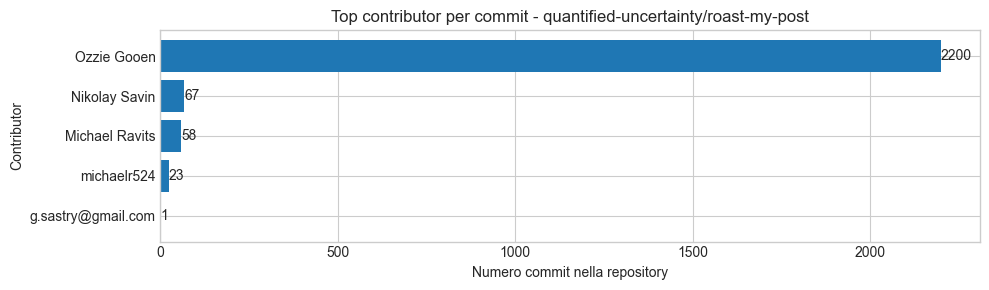

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,f6e936a382879eda012023e3909523b4c9219666,Michael Ravits,2026-01-24T19:37:26Z,1,75,0,75,feat(ai): Fallacy checker refactor with profile system and Lab UI,https://github.com/quantified-uncertainty/roast-my-post/compare/94a95e8a082c276f9eba226caad348c0f9be23b3...f6e936a382879eda012023e3909523b4c9219666
1,758d234501b06ea606c18e514760669f6180b8b3,Michael Ravits,2025-12-25T11:21:55Z,1,44,26,70,feat: Add meta-evaluation framework for agent quality measurement (#377),https://github.com/quantified-uncertainty/roast-my-post/compare/9d3ca48acdf66c24d165e4a9bd756c76c1529af0...758d234501b06ea606c18e514760669f6180b8b3
2,94a95e8a082c276f9eba226caad348c0f9be23b3,michaelr524,2025-12-31T14:06:47Z,1,44,26,70,feat: Meta-evaluation framework for agent quality measurement (#382),https://github.com/quantified-uncertainty/roast-my-post/compare/dff0f0748fe0a66bc374d6305f437254cdb445f2...94a95e8a082c276f9eba226caad348c0f9be23b3
3,dff0f0748fe0a66bc374d6305f437254cdb445f2,Michael Ravits,2025-12-25T12:53:29Z,1,26,44,70,"Revert ""feat: Add meta-evaluation framework for agent quality measurement (#377)""",https://github.com/quantified-uncertainty/roast-my-post/compare/758d234501b06ea606c18e514760669f6180b8b3...dff0f0748fe0a66bc374d6305f437254cdb445f2
4,9d3ca48acdf66c24d165e4a9bd756c76c1529af0,Ozzie Gooen,2025-10-09T23:16:34Z,1,40,0,40,feat(claim-evaluator): add database storage for evaluations,https://github.com/quantified-uncertainty/roast-my-post/compare/b2b75d4d6d445d97a8b04b608647f91f59af67ed...9d3ca48acdf66c24d165e4a9bd756c76c1529af0
5,b2b75d4d6d445d97a8b04b608647f91f59af67ed,Ozzie Gooen,2025-09-01T02:56:28Z,1,13,8,21,Improved claude docs,https://github.com/quantified-uncertainty/roast-my-post/compare/23cdf6c758224d48227fe734a3cd57fd833526f6...b2b75d4d6d445d97a8b04b608647f91f59af67ed
6,f1fffabab257bd7ba45c3e82bbb9865e2df1969b,michaelr524,2026-03-06T11:21:38Z,1,21,0,21,fix: Add error handlers to prevent worker crash on pg-boss errors (#405),https://github.com/quantified-uncertainty/roast-my-post/compare/c686c3c37279646bc0ffc4be091209ee2f10d2d8...f1fffabab257bd7ba45c3e82bbb9865e2df1969b
7,1886702b5ceae0ccbbbe6f0889929d5d48b18c1b,Michael Ravits,2026-01-24T20:30:59Z,1,11,0,11,"fix: Cost calculation, Zod validation, and docs updates",https://github.com/quantified-uncertainty/roast-my-post/compare/f6e936a382879eda012023e3909523b4c9219666...1886702b5ceae0ccbbbe6f0889929d5d48b18c1b
8,c686c3c37279646bc0ffc4be091209ee2f10d2d8,michaelr524,2026-03-03T14:26:27Z,1,3,0,3,New agentic analysis plugin using the Claude Agent SDK (#390),https://github.com/quantified-uncertainty/roast-my-post/compare/1886702b5ceae0ccbbbe6f0889929d5d48b18c1b...c686c3c37279646bc0ffc4be091209ee2f10d2d8
9,1259a0aab45ca5e46f673052bc89761f89409d9b,Michael Ravits,2026-03-15T18:03:59Z,1,1,1,2,fix: Correct stern command for staging in CLAUDE.md,https://github.com/quantified-uncertainty/roast-my-post/compare/f1fffabab257bd7ba45c3e82bbb9865e2df1969b...1259a0aab45ca5e46f673052bc89761f89409d9b


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,f6e936a382879eda012023e3909523b4c9219666,Michael Ravits,2026-01-24T19:37:26Z,75,75,0,1,feat(ai): Fallacy checker refactor with profile system and Lab UI,https://github.com/quantified-uncertainty/roast-my-post/compare/94a95e8a082c276f9eba226caad348c0f9be23b3...f6e936a382879eda012023e3909523b4c9219666
1,758d234501b06ea606c18e514760669f6180b8b3,Michael Ravits,2025-12-25T11:21:55Z,70,44,26,1,feat: Add meta-evaluation framework for agent quality measurement (#377),https://github.com/quantified-uncertainty/roast-my-post/compare/9d3ca48acdf66c24d165e4a9bd756c76c1529af0...758d234501b06ea606c18e514760669f6180b8b3
2,dff0f0748fe0a66bc374d6305f437254cdb445f2,Michael Ravits,2025-12-25T12:53:29Z,70,26,44,1,"Revert ""feat: Add meta-evaluation framework for agent quality measurement (#377)""",https://github.com/quantified-uncertainty/roast-my-post/compare/758d234501b06ea606c18e514760669f6180b8b3...dff0f0748fe0a66bc374d6305f437254cdb445f2
3,94a95e8a082c276f9eba226caad348c0f9be23b3,michaelr524,2025-12-31T14:06:47Z,70,44,26,1,feat: Meta-evaluation framework for agent quality measurement (#382),https://github.com/quantified-uncertainty/roast-my-post/compare/dff0f0748fe0a66bc374d6305f437254cdb445f2...94a95e8a082c276f9eba226caad348c0f9be23b3
4,9d3ca48acdf66c24d165e4a9bd756c76c1529af0,Ozzie Gooen,2025-10-09T23:16:34Z,40,40,0,1,feat(claim-evaluator): add database storage for evaluations,https://github.com/quantified-uncertainty/roast-my-post/compare/b2b75d4d6d445d97a8b04b608647f91f59af67ed...9d3ca48acdf66c24d165e4a9bd756c76c1529af0
5,b2b75d4d6d445d97a8b04b608647f91f59af67ed,Ozzie Gooen,2025-09-01T02:56:28Z,21,13,8,1,Improved claude docs,https://github.com/quantified-uncertainty/roast-my-post/compare/23cdf6c758224d48227fe734a3cd57fd833526f6...b2b75d4d6d445d97a8b04b608647f91f59af67ed
6,f1fffabab257bd7ba45c3e82bbb9865e2df1969b,michaelr524,2026-03-06T11:21:38Z,21,21,0,1,fix: Add error handlers to prevent worker crash on pg-boss errors (#405),https://github.com/quantified-uncertainty/roast-my-post/compare/c686c3c37279646bc0ffc4be091209ee2f10d2d8...f1fffabab257bd7ba45c3e82bbb9865e2df1969b
7,1886702b5ceae0ccbbbe6f0889929d5d48b18c1b,Michael Ravits,2026-01-24T20:30:59Z,11,11,0,1,"fix: Cost calculation, Zod validation, and docs updates",https://github.com/quantified-uncertainty/roast-my-post/compare/f6e936a382879eda012023e3909523b4c9219666...1886702b5ceae0ccbbbe6f0889929d5d48b18c1b
8,c686c3c37279646bc0ffc4be091209ee2f10d2d8,michaelr524,2026-03-03T14:26:27Z,3,3,0,1,New agentic analysis plugin using the Claude Agent SDK (#390),https://github.com/quantified-uncertainty/roast-my-post/compare/1886702b5ceae0ccbbbe6f0889929d5d48b18c1b...c686c3c37279646bc0ffc4be091209ee2f10d2d8
9,1259a0aab45ca5e46f673052bc89761f89409d9b,Michael Ravits,2026-03-15T18:03:59Z,2,1,1,1,fix: Correct stern command for staging in CLAUDE.md,https://github.com/quantified-uncertainty/roast-my-post/compare/f1fffabab257bd7ba45c3e82bbb9865e2df1969b...1259a0aab45ca5e46f673052bc89761f89409d9b


In [16]:
show_repo_report("quantified-uncertainty/roast-my-post")

## ryoppippi/ccusage

### Contributor nella repository

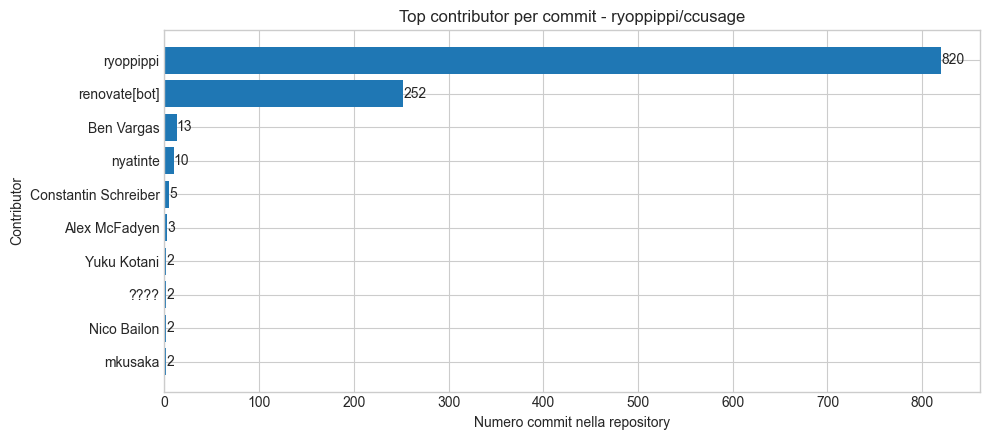

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,301328ac953a5c5a92bae78bfe7ed80d56abb315,ryoppippi,2025-09-18T17:41:40Z,1,67,0,67,docs: add Git commit and PR conventions to CLAUDE.md (#646),https://github.com/ryoppippi/ccusage/compare/fead57666d1dd8e01dcfbb84068980322817ec52...301328ac953a5c5a92bae78bfe7ed80d56abb315
1,4d8b2e187e1d9e9f11f6b3a047a6988b5499e73b,ryoppippi,2025-09-17T01:00:27Z,1,29,29,58,feat: monorepo(bun -> pnpm) (#631),https://github.com/ryoppippi/ccusage/compare/f6798c0251c5a6f5f1609a8d72fcae5fd8ab92a9...4d8b2e187e1d9e9f11f6b3a047a6988b5499e73b
2,1c68b43e3b60d3de1f8f02ebdb10d4466170042f,ryoppippi,2025-11-25T14:41:37Z,1,0,45,45,chore: remove lsmcp integration (#728),https://github.com/ryoppippi/ccusage/compare/301328ac953a5c5a92bae78bfe7ed80d56abb315...1c68b43e3b60d3de1f8f02ebdb10d4466170042f
3,d7e6993cc57852e693b0df86ab3904e3c118fa97,NaN,NaN,1,0,30,30,NaN,https://github.com/ryoppippi/ccusage/compare/98275591f9056951e0cd321cd982bc5ee92e5276...d7e6993cc57852e693b0df86ab3904e3c118fa97
4,6a5941145342b9a3d5f71ee30e517f73b696863c,ryoppippi,2025-09-17T11:07:34Z,1,13,3,16,feat: extract MCP server into dedicated package (#632),https://github.com/ryoppippi/ccusage/compare/4d8b2e187e1d9e9f11f6b3a047a6988b5499e73b...6a5941145342b9a3d5f71ee30e517f73b696863c
5,98275591f9056951e0cd321cd982bc5ee92e5276,ryoppippi,2026-01-09T12:22:08Z,1,6,4,10,chore: migrate MCP servers for docs to docs packages (#786),https://github.com/ryoppippi/ccusage/compare/397ca8edd1136d81f985f4bf5d0aaf73e2b76e20...98275591f9056951e0cd321cd982bc5ee92e5276
6,c7156aaaabc0bc50d570bbe4fb4cafdbdd07de87,ryoppippi,2025-09-17T18:27:17Z,1,2,2,4,refactor: rename packages directory to apps for improved monorepo semantics (#639),https://github.com/ryoppippi/ccusage/compare/6a5941145342b9a3d5f71ee30e517f73b696863c...c7156aaaabc0bc50d570bbe4fb4cafdbdd07de87
7,fead57666d1dd8e01dcfbb84068980322817ec52,ryoppippi,2025-09-18T16:04:23Z,1,4,0,4,feat: codex (#641),https://github.com/ryoppippi/ccusage/compare/c7156aaaabc0bc50d570bbe4fb4cafdbdd07de87...fead57666d1dd8e01dcfbb84068980322817ec52
8,397ca8edd1136d81f985f4bf5d0aaf73e2b76e20,Anish De,2026-01-09T11:06:29Z,1,2,0,2,feat(opencode): add OpenCode CLI package (#758),https://github.com/ryoppippi/ccusage/compare/1c68b43e3b60d3de1f8f02ebdb10d4466170042f...397ca8edd1136d81f985f4bf5d0aaf73e2b76e20
9,f6798c0251c5a6f5f1609a8d72fcae5fd8ab92a9,ryoppippi,2025-08-24T22:49:12Z,1,1,0,1,docs: emphasize no dynamic imports and vitest globals in CLAUDE.md,https://github.com/ryoppippi/ccusage/compare/53f75ee11a66b4606dd59ea4fa2bb020127c4068...f6798c0251c5a6f5f1609a8d72fcae5fd8ab92a9


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,301328ac953a5c5a92bae78bfe7ed80d56abb315,ryoppippi,2025-09-18T17:41:40Z,67,67,0,1,docs: add Git commit and PR conventions to CLAUDE.md (#646),https://github.com/ryoppippi/ccusage/compare/fead57666d1dd8e01dcfbb84068980322817ec52...301328ac953a5c5a92bae78bfe7ed80d56abb315
1,4d8b2e187e1d9e9f11f6b3a047a6988b5499e73b,ryoppippi,2025-09-17T01:00:27Z,58,29,29,1,feat: monorepo(bun -> pnpm) (#631),https://github.com/ryoppippi/ccusage/compare/f6798c0251c5a6f5f1609a8d72fcae5fd8ab92a9...4d8b2e187e1d9e9f11f6b3a047a6988b5499e73b
2,1c68b43e3b60d3de1f8f02ebdb10d4466170042f,ryoppippi,2025-11-25T14:41:37Z,45,0,45,1,chore: remove lsmcp integration (#728),https://github.com/ryoppippi/ccusage/compare/301328ac953a5c5a92bae78bfe7ed80d56abb315...1c68b43e3b60d3de1f8f02ebdb10d4466170042f
3,d7e6993cc57852e693b0df86ab3904e3c118fa97,NaN,NaN,30,0,30,1,NaN,https://github.com/ryoppippi/ccusage/compare/98275591f9056951e0cd321cd982bc5ee92e5276...d7e6993cc57852e693b0df86ab3904e3c118fa97
4,6a5941145342b9a3d5f71ee30e517f73b696863c,ryoppippi,2025-09-17T11:07:34Z,16,13,3,1,feat: extract MCP server into dedicated package (#632),https://github.com/ryoppippi/ccusage/compare/4d8b2e187e1d9e9f11f6b3a047a6988b5499e73b...6a5941145342b9a3d5f71ee30e517f73b696863c
5,98275591f9056951e0cd321cd982bc5ee92e5276,ryoppippi,2026-01-09T12:22:08Z,10,6,4,1,chore: migrate MCP servers for docs to docs packages (#786),https://github.com/ryoppippi/ccusage/compare/397ca8edd1136d81f985f4bf5d0aaf73e2b76e20...98275591f9056951e0cd321cd982bc5ee92e5276
6,fead57666d1dd8e01dcfbb84068980322817ec52,ryoppippi,2025-09-18T16:04:23Z,4,4,0,1,feat: codex (#641),https://github.com/ryoppippi/ccusage/compare/c7156aaaabc0bc50d570bbe4fb4cafdbdd07de87...fead57666d1dd8e01dcfbb84068980322817ec52
7,c7156aaaabc0bc50d570bbe4fb4cafdbdd07de87,ryoppippi,2025-09-17T18:27:17Z,4,2,2,1,refactor: rename packages directory to apps for improved monorepo semantics (#639),https://github.com/ryoppippi/ccusage/compare/6a5941145342b9a3d5f71ee30e517f73b696863c...c7156aaaabc0bc50d570bbe4fb4cafdbdd07de87
8,397ca8edd1136d81f985f4bf5d0aaf73e2b76e20,Anish De,2026-01-09T11:06:29Z,2,2,0,1,feat(opencode): add OpenCode CLI package (#758),https://github.com/ryoppippi/ccusage/compare/1c68b43e3b60d3de1f8f02ebdb10d4466170042f...397ca8edd1136d81f985f4bf5d0aaf73e2b76e20
9,f6798c0251c5a6f5f1609a8d72fcae5fd8ab92a9,ryoppippi,2025-08-24T22:49:12Z,1,1,0,1,docs: emphasize no dynamic imports and vitest globals in CLAUDE.md,https://github.com/ryoppippi/ccusage/compare/53f75ee11a66b4606dd59ea4fa2bb020127c4068...f6798c0251c5a6f5f1609a8d72fcae5fd8ab92a9


In [17]:
show_repo_report("ryoppippi/ccusage")

## steipete/Peekaboo

### Contributor nella repository

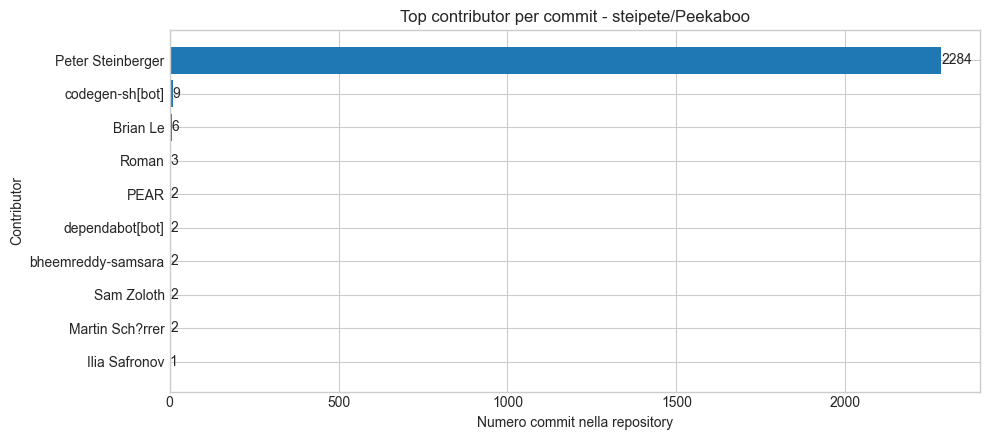

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,cdcc9504826fe923b7d903a1a4f32c630ececb9e,Peter Steinberger,2025-08-04T22:28:09Z,1,50,444,494,Restore CLAUDE.md to cleaned up version,https://github.com/openclaw/Peekaboo/compare/215788eec49bfb1d1b50548deb9ab1271c130bc1...cdcc9504826fe923b7d903a1a4f32c630ececb9e
1,27ac539656c0f029d3c6c1291763405b8cc048a0,Peter Steinberger,2025-08-07T10:44:13Z,1,34,240,274,feat: Expose all Peekaboo tools to agent and fix API issues,https://github.com/openclaw/Peekaboo/compare/2c3b95824af4dce650c7faa9ff7d08b85d0764f9...27ac539656c0f029d3c6c1291763405b8cc048a0
2,215788eec49bfb1d1b50548deb9ab1271c130bc1,Peter Steinberger,2025-08-04T22:03:15Z,1,76,6,82,Fix CI configuration for Tachikoma integration,https://github.com/openclaw/Peekaboo/compare/e5975bf6f158c48ac2bc665b22681adab1317a93...215788eec49bfb1d1b50548deb9ab1271c130bc1
3,5e338556afda3f60c0fd5c60aea3af3d07767774,Peter Steinberger,2025-08-04T22:31:43Z,1,2,70,72,Fix inaccuracies and remove duplicates in CLAUDE.md,https://github.com/openclaw/Peekaboo/compare/cdcc9504826fe923b7d903a1a4f32c630ececb9e...5e338556afda3f60c0fd5c60aea3af3d07767774
4,e7320105a285839f523bfb072fcba7dc099f3930,Peter Steinberger,2025-08-08T01:49:22Z,1,14,11,25,fix: restore image analysis via GPT-5 and config-driven providers,https://github.com/openclaw/Peekaboo/compare/53353add5d9d74017c158a73c67fc690c59f4043...e7320105a285839f523bfb072fcba7dc099f3930
5,2c3b95824af4dce650c7faa9ff7d08b85d0764f9,Peter Steinberger,2025-08-06T17:44:36Z,1,15,0,15,Fix API key management and environment variable detection,https://github.com/openclaw/Peekaboo/compare/12fe56ea94e61be89a09d0645a1d119a3aa177c2...2c3b95824af4dce650c7faa9ff7d08b85d0764f9
6,53353add5d9d74017c158a73c67fc690c59f4043,Peter Steinberger,2025-08-07T22:39:05Z,1,5,1,6,feat: Make GPT-5 the default agent model with preamble message support,https://github.com/openclaw/Peekaboo/compare/2c05db8f86e1c4e9cd544d41ab8b5354c769edc5...53353add5d9d74017c158a73c67fc690c59f4043
7,2c05db8f86e1c4e9cd544d41ab8b5354c769edc5,Peter Steinberger,2025-08-07T21:52:04Z,1,2,0,2,docs: Add GPT-5 availability note to CLAUDE.md,https://github.com/openclaw/Peekaboo/compare/27ac539656c0f029d3c6c1291763405b8cc048a0...2c05db8f86e1c4e9cd544d41ab8b5354c769edc5
8,12fe56ea94e61be89a09d0645a1d119a3aa177c2,Peter Steinberger,2025-08-06T17:15:44Z,1,1,0,1,Fix Tachikoma dependency conflict,https://github.com/openclaw/Peekaboo/compare/5e338556afda3f60c0fd5c60aea3af3d07767774...12fe56ea94e61be89a09d0645a1d119a3aa177c2
9,a5be930bd782d8a15f6451ebf7605b200caa6b7e,Peter Steinberger,2025-11-05T12:23:48Z,1,0,0,0,style: reformat shared modules and guides,https://github.com/openclaw/Peekaboo/compare/e7320105a285839f523bfb072fcba7dc099f3930...a5be930bd782d8a15f6451ebf7605b200caa6b7e


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,cdcc9504826fe923b7d903a1a4f32c630ececb9e,Peter Steinberger,2025-08-04T22:28:09Z,494,50,444,1,Restore CLAUDE.md to cleaned up version,https://github.com/openclaw/Peekaboo/compare/215788eec49bfb1d1b50548deb9ab1271c130bc1...cdcc9504826fe923b7d903a1a4f32c630ececb9e
1,27ac539656c0f029d3c6c1291763405b8cc048a0,Peter Steinberger,2025-08-07T10:44:13Z,274,34,240,1,feat: Expose all Peekaboo tools to agent and fix API issues,https://github.com/openclaw/Peekaboo/compare/2c3b95824af4dce650c7faa9ff7d08b85d0764f9...27ac539656c0f029d3c6c1291763405b8cc048a0
2,215788eec49bfb1d1b50548deb9ab1271c130bc1,Peter Steinberger,2025-08-04T22:03:15Z,82,76,6,1,Fix CI configuration for Tachikoma integration,https://github.com/openclaw/Peekaboo/compare/e5975bf6f158c48ac2bc665b22681adab1317a93...215788eec49bfb1d1b50548deb9ab1271c130bc1
3,5e338556afda3f60c0fd5c60aea3af3d07767774,Peter Steinberger,2025-08-04T22:31:43Z,72,2,70,1,Fix inaccuracies and remove duplicates in CLAUDE.md,https://github.com/openclaw/Peekaboo/compare/cdcc9504826fe923b7d903a1a4f32c630ececb9e...5e338556afda3f60c0fd5c60aea3af3d07767774
4,e7320105a285839f523bfb072fcba7dc099f3930,Peter Steinberger,2025-08-08T01:49:22Z,25,14,11,1,fix: restore image analysis via GPT-5 and config-driven providers,https://github.com/openclaw/Peekaboo/compare/53353add5d9d74017c158a73c67fc690c59f4043...e7320105a285839f523bfb072fcba7dc099f3930
5,2c3b95824af4dce650c7faa9ff7d08b85d0764f9,Peter Steinberger,2025-08-06T17:44:36Z,15,15,0,1,Fix API key management and environment variable detection,https://github.com/openclaw/Peekaboo/compare/12fe56ea94e61be89a09d0645a1d119a3aa177c2...2c3b95824af4dce650c7faa9ff7d08b85d0764f9
6,53353add5d9d74017c158a73c67fc690c59f4043,Peter Steinberger,2025-08-07T22:39:05Z,6,5,1,1,feat: Make GPT-5 the default agent model with preamble message support,https://github.com/openclaw/Peekaboo/compare/2c05db8f86e1c4e9cd544d41ab8b5354c769edc5...53353add5d9d74017c158a73c67fc690c59f4043
7,2c05db8f86e1c4e9cd544d41ab8b5354c769edc5,Peter Steinberger,2025-08-07T21:52:04Z,2,2,0,1,docs: Add GPT-5 availability note to CLAUDE.md,https://github.com/openclaw/Peekaboo/compare/27ac539656c0f029d3c6c1291763405b8cc048a0...2c05db8f86e1c4e9cd544d41ab8b5354c769edc5
8,12fe56ea94e61be89a09d0645a1d119a3aa177c2,Peter Steinberger,2025-08-06T17:15:44Z,1,1,0,1,Fix Tachikoma dependency conflict,https://github.com/openclaw/Peekaboo/compare/5e338556afda3f60c0fd5c60aea3af3d07767774...12fe56ea94e61be89a09d0645a1d119a3aa177c2
9,a5be930bd782d8a15f6451ebf7605b200caa6b7e,Peter Steinberger,2025-11-05T12:23:48Z,0,0,0,1,style: reformat shared modules and guides,https://github.com/openclaw/Peekaboo/compare/e7320105a285839f523bfb072fcba7dc099f3930...a5be930bd782d8a15f6451ebf7605b200caa6b7e


In [18]:
show_repo_report("steipete/Peekaboo")

## sugyan/claude-code-webui

### Contributor nella repository

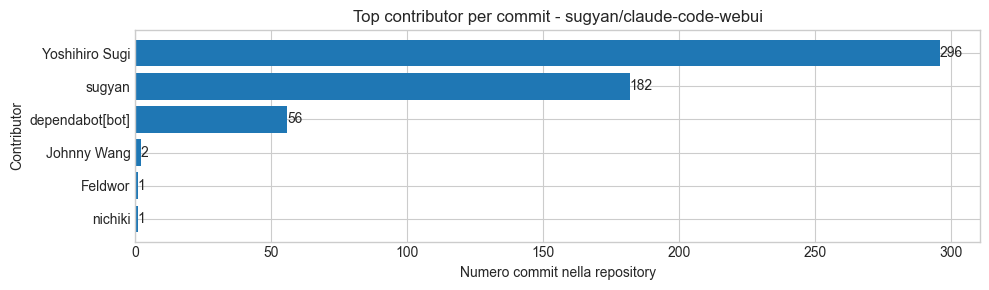

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,86a78e0104ecdf23c167ec1103a315caa3a45407,Yoshihiro Sugi,2025-08-30T14:00:20Z,1,131,741,872,docs: optimize CLAUDE.md for better performance (#261),https://github.com/sugyan/claude-code-webui/compare/de6e4b36aecf4234e869e5cdf7f26469c2928a0c...86a78e0104ecdf23c167ec1103a315caa3a45407
1,1122cd9e3d8bcb3f033acfb3d6c634c692779a71,Yoshihiro Sugi,2025-07-26T13:37:18Z,1,109,13,122,feat: replace blocking modal permission dialog with inline interface (#203),https://github.com/sugyan/claude-code-webui/compare/c6b887d2d721dbfabf5c5fa27e5ea743f5bb2889...1122cd9e3d8bcb3f033acfb3d6c634c692779a71
2,333fddddfed777905fecff2ac9aa498cdcbfc264,Yoshihiro Sugi,2025-07-14T01:28:47Z,1,61,22,83,docs: update CLAUDE.md to reflect current implementation (#187),https://github.com/sugyan/claude-code-webui/compare/0090a2f616ef7b76dfa38f59247c8228dff10301...333fddddfed777905fecff2ac9aa498cdcbfc264
3,c6b887d2d721dbfabf5c5fa27e5ea743f5bb2889,Yoshihiro Sugi,2025-07-19T14:10:37Z,1,48,17,65,feat: Universal Claude CLI path detection with detectClaudeCliPath (#194),https://github.com/sugyan/claude-code-webui/compare/333fddddfed777905fecff2ac9aa498cdcbfc264...c6b887d2d721dbfabf5c5fa27e5ea743f5bb2889
4,acb82f5652f1069fe01dd7938aaa296935b1093c,Yoshihiro Sugi,2025-07-31T14:16:33Z,1,27,18,45,feat: implement LogTape logging system for debug log control (#220),https://github.com/sugyan/claude-code-webui/compare/28ed92d647693213748b7ac0847d9aabdec2753a...acb82f5652f1069fe01dd7938aaa296935b1093c
5,3d56f22a8518c42caaf824053f41e2f894e29b91,Yoshihiro Sugi,2025-08-22T11:26:36Z,1,44,0,44,docs: add Permission Mode feature documentation (#239),https://github.com/sugyan/claude-code-webui/compare/acb82f5652f1069fe01dd7938aaa296935b1093c...3d56f22a8518c42caaf824053f41e2f894e29b91
6,28ed92d647693213748b7ac0847d9aabdec2753a,Yoshihiro Sugi,2025-07-27T13:18:51Z,1,10,10,20,chore: cleanup documentation and remove unused files (#210),https://github.com/sugyan/claude-code-webui/compare/9b58ed6365984403946ee8c099a2cd1ad73c8615...28ed92d647693213748b7ac0847d9aabdec2753a
7,de6e4b36aecf4234e869e5cdf7f26469c2928a0c,Yoshihiro Sugi,2025-08-29T14:07:08Z,1,18,2,20,Enhanced TodoWrite display with visual todo list (#259),https://github.com/sugyan/claude-code-webui/compare/3d56f22a8518c42caaf824053f41e2f894e29b91...de6e4b36aecf4234e869e5cdf7f26469c2928a0c
8,04aece1f3fce8d7d418defda6f1625b87165870f,Yoshihiro Sugi,2025-09-06T14:47:39Z,1,4,1,5,Fix Claude CLI validation to use fallback instead of exit on detection failure (#270),https://github.com/sugyan/claude-code-webui/compare/86a78e0104ecdf23c167ec1103a315caa3a45407...04aece1f3fce8d7d418defda6f1625b87165870f
9,9b58ed6365984403946ee8c099a2cd1ad73c8615,Yoshihiro Sugi,2025-07-26T15:01:06Z,1,1,1,2,chore: update @anthropic-ai/claude-code to version 1.0.61 (#206),https://github.com/sugyan/claude-code-webui/compare/1122cd9e3d8bcb3f033acfb3d6c634c692779a71...9b58ed6365984403946ee8c099a2cd1ad73c8615


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,86a78e0104ecdf23c167ec1103a315caa3a45407,Yoshihiro Sugi,2025-08-30T14:00:20Z,872,131,741,1,docs: optimize CLAUDE.md for better performance (#261),https://github.com/sugyan/claude-code-webui/compare/de6e4b36aecf4234e869e5cdf7f26469c2928a0c...86a78e0104ecdf23c167ec1103a315caa3a45407
1,1122cd9e3d8bcb3f033acfb3d6c634c692779a71,Yoshihiro Sugi,2025-07-26T13:37:18Z,122,109,13,1,feat: replace blocking modal permission dialog with inline interface (#203),https://github.com/sugyan/claude-code-webui/compare/c6b887d2d721dbfabf5c5fa27e5ea743f5bb2889...1122cd9e3d8bcb3f033acfb3d6c634c692779a71
2,333fddddfed777905fecff2ac9aa498cdcbfc264,Yoshihiro Sugi,2025-07-14T01:28:47Z,83,61,22,1,docs: update CLAUDE.md to reflect current implementation (#187),https://github.com/sugyan/claude-code-webui/compare/0090a2f616ef7b76dfa38f59247c8228dff10301...333fddddfed777905fecff2ac9aa498cdcbfc264
3,c6b887d2d721dbfabf5c5fa27e5ea743f5bb2889,Yoshihiro Sugi,2025-07-19T14:10:37Z,65,48,17,1,feat: Universal Claude CLI path detection with detectClaudeCliPath (#194),https://github.com/sugyan/claude-code-webui/compare/333fddddfed777905fecff2ac9aa498cdcbfc264...c6b887d2d721dbfabf5c5fa27e5ea743f5bb2889
4,acb82f5652f1069fe01dd7938aaa296935b1093c,Yoshihiro Sugi,2025-07-31T14:16:33Z,45,27,18,1,feat: implement LogTape logging system for debug log control (#220),https://github.com/sugyan/claude-code-webui/compare/28ed92d647693213748b7ac0847d9aabdec2753a...acb82f5652f1069fe01dd7938aaa296935b1093c
5,3d56f22a8518c42caaf824053f41e2f894e29b91,Yoshihiro Sugi,2025-08-22T11:26:36Z,44,44,0,1,docs: add Permission Mode feature documentation (#239),https://github.com/sugyan/claude-code-webui/compare/acb82f5652f1069fe01dd7938aaa296935b1093c...3d56f22a8518c42caaf824053f41e2f894e29b91
6,de6e4b36aecf4234e869e5cdf7f26469c2928a0c,Yoshihiro Sugi,2025-08-29T14:07:08Z,20,18,2,1,Enhanced TodoWrite display with visual todo list (#259),https://github.com/sugyan/claude-code-webui/compare/3d56f22a8518c42caaf824053f41e2f894e29b91...de6e4b36aecf4234e869e5cdf7f26469c2928a0c
7,28ed92d647693213748b7ac0847d9aabdec2753a,Yoshihiro Sugi,2025-07-27T13:18:51Z,20,10,10,1,chore: cleanup documentation and remove unused files (#210),https://github.com/sugyan/claude-code-webui/compare/9b58ed6365984403946ee8c099a2cd1ad73c8615...28ed92d647693213748b7ac0847d9aabdec2753a
8,04aece1f3fce8d7d418defda6f1625b87165870f,Yoshihiro Sugi,2025-09-06T14:47:39Z,5,4,1,1,Fix Claude CLI validation to use fallback instead of exit on detection failure (#270),https://github.com/sugyan/claude-code-webui/compare/86a78e0104ecdf23c167ec1103a315caa3a45407...04aece1f3fce8d7d418defda6f1625b87165870f
9,9b58ed6365984403946ee8c099a2cd1ad73c8615,Yoshihiro Sugi,2025-07-26T15:01:06Z,2,1,1,1,chore: update @anthropic-ai/claude-code to version 1.0.61 (#206),https://github.com/sugyan/claude-code-webui/compare/1122cd9e3d8bcb3f033acfb3d6c634c692779a71...9b58ed6365984403946ee8c099a2cd1ad73c8615


In [19]:
show_repo_report("sugyan/claude-code-webui")

## tphakala/birdnet-go

### Contributor nella repository

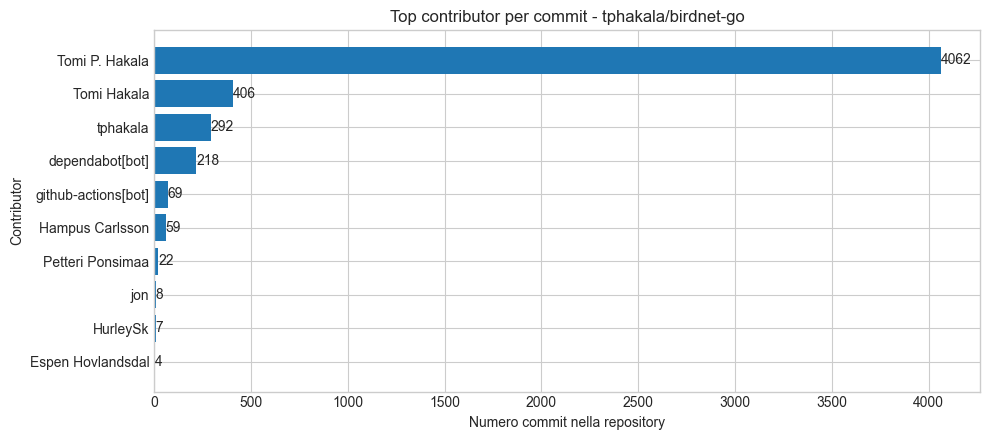

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,aafd891bf982aa94602e7be5cfffdffa83b372dc,Tomi P. Hakala,2026-04-28T07:15:01Z,1,48,0,48,docs: add QA testing framework section to CLAUDE.md,https://github.com/tphakala/birdnet-go/compare/ed362ae1cd3d7fda7bf360329b03f855d9d8a42e...aafd891bf982aa94602e7be5cfffdffa83b372dc
1,bc3b1848523ee7a5c7b264a60955a2291a2786f8,Tomi P. Hakala,2025-08-10T08:43:54Z,1,42,0,42,feat: integrate ast-grep for enhanced frontend static analysis (#1124),https://github.com/tphakala/birdnet-go/compare/3710bb6d6812784213ba73d37139bcbaebd9681a...bc3b1848523ee7a5c7b264a60955a2291a2786f8
2,c9f56642c4c0d3b9820edab3e2bf39a6d1aea417,Tomi P. Hakala,2026-01-13T11:54:43Z,1,29,0,29,feat: stream configuration redesign with named streams and multi-protocol support (#1764),https://github.com/tphakala/birdnet-go/compare/5b37c05399d870ba8219a021abae92c11c8f7444...c9f56642c4c0d3b9820edab3e2bf39a6d1aea417
3,f1b49011bfa2a05554e1985e8c6e04d9a037696b,Tomi P. Hakala,2025-09-14T08:59:38Z,1,5,0,5,docs: Add Go 1.25 testing features and upgrade infrastructure (#1291),https://github.com/tphakala/birdnet-go/compare/c0cac35eec6b0a2d6b6363d6451132384643af84...f1b49011bfa2a05554e1985e8c6e04d9a037696b
4,c0cac35eec6b0a2d6b6363d6451132384643af84,Tomi P. Hakala,2025-08-20T11:02:19Z,1,2,2,4,docs: improve formatting and clarity in documentation files,https://github.com/tphakala/birdnet-go/compare/bc3b1848523ee7a5c7b264a60955a2291a2786f8...c0cac35eec6b0a2d6b6363d6451132384643af84
5,bb776fdff5ada1c60ef45978a6e2267ecafdb33e,Tomi P. Hakala,2025-12-25T10:06:51Z,1,2,0,2,docs: update CLAUDE.md to include testing guidelines and emphasize testify usage,https://github.com/tphakala/birdnet-go/compare/6fc693ecd1602a25b443d64b2ef8cb845a82a400...bb776fdff5ada1c60ef45978a6e2267ecafdb33e
6,5b37c05399d870ba8219a021abae92c11c8f7444,Tomi P. Hakala,2025-12-25T12:57:07Z,1,1,0,1,docs: add rule against magic numbers/strings in CLAUDE.md,https://github.com/tphakala/birdnet-go/compare/bb776fdff5ada1c60ef45978a6e2267ecafdb33e...5b37c05399d870ba8219a021abae92c11c8f7444
7,6fc693ecd1602a25b443d64b2ef8cb845a82a400,Tomi P. Hakala,2025-10-21T08:55:19Z,1,1,0,1,docs: comprehensive contributing guide with automated dev setup (#1424),https://github.com/tphakala/birdnet-go/compare/f1b49011bfa2a05554e1985e8c6e04d9a037696b...6fc693ecd1602a25b443d64b2ef8cb845a82a400
8,7d931cf7c8e0bb0e25564ff9bd3332a5680c19a3,Tomi P. Hakala,2026-03-16T20:02:31Z,1,1,0,1,fix: support hot-reload for public live audio setting (#2359),https://github.com/tphakala/birdnet-go/compare/c9f56642c4c0d3b9820edab3e2bf39a6d1aea417...7d931cf7c8e0bb0e25564ff9bd3332a5680c19a3
9,ed362ae1cd3d7fda7bf360329b03f855d9d8a42e,Tomi P. Hakala,2026-03-16T20:13:37Z,1,1,0,1,fix: retry audio device validation on startup for USB devices (#2360),https://github.com/tphakala/birdnet-go/compare/7d931cf7c8e0bb0e25564ff9bd3332a5680c19a3...ed362ae1cd3d7fda7bf360329b03f855d9d8a42e


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,aafd891bf982aa94602e7be5cfffdffa83b372dc,Tomi P. Hakala,2026-04-28T07:15:01Z,48,48,0,1,docs: add QA testing framework section to CLAUDE.md,https://github.com/tphakala/birdnet-go/compare/ed362ae1cd3d7fda7bf360329b03f855d9d8a42e...aafd891bf982aa94602e7be5cfffdffa83b372dc
1,bc3b1848523ee7a5c7b264a60955a2291a2786f8,Tomi P. Hakala,2025-08-10T08:43:54Z,42,42,0,1,feat: integrate ast-grep for enhanced frontend static analysis (#1124),https://github.com/tphakala/birdnet-go/compare/3710bb6d6812784213ba73d37139bcbaebd9681a...bc3b1848523ee7a5c7b264a60955a2291a2786f8
2,c9f56642c4c0d3b9820edab3e2bf39a6d1aea417,Tomi P. Hakala,2026-01-13T11:54:43Z,29,29,0,1,feat: stream configuration redesign with named streams and multi-protocol support (#1764),https://github.com/tphakala/birdnet-go/compare/5b37c05399d870ba8219a021abae92c11c8f7444...c9f56642c4c0d3b9820edab3e2bf39a6d1aea417
3,f1b49011bfa2a05554e1985e8c6e04d9a037696b,Tomi P. Hakala,2025-09-14T08:59:38Z,5,5,0,1,docs: Add Go 1.25 testing features and upgrade infrastructure (#1291),https://github.com/tphakala/birdnet-go/compare/c0cac35eec6b0a2d6b6363d6451132384643af84...f1b49011bfa2a05554e1985e8c6e04d9a037696b
4,c0cac35eec6b0a2d6b6363d6451132384643af84,Tomi P. Hakala,2025-08-20T11:02:19Z,4,2,2,1,docs: improve formatting and clarity in documentation files,https://github.com/tphakala/birdnet-go/compare/bc3b1848523ee7a5c7b264a60955a2291a2786f8...c0cac35eec6b0a2d6b6363d6451132384643af84
5,bb776fdff5ada1c60ef45978a6e2267ecafdb33e,Tomi P. Hakala,2025-12-25T10:06:51Z,2,2,0,1,docs: update CLAUDE.md to include testing guidelines and emphasize testify usage,https://github.com/tphakala/birdnet-go/compare/6fc693ecd1602a25b443d64b2ef8cb845a82a400...bb776fdff5ada1c60ef45978a6e2267ecafdb33e
6,6fc693ecd1602a25b443d64b2ef8cb845a82a400,Tomi P. Hakala,2025-10-21T08:55:19Z,1,1,0,1,docs: comprehensive contributing guide with automated dev setup (#1424),https://github.com/tphakala/birdnet-go/compare/f1b49011bfa2a05554e1985e8c6e04d9a037696b...6fc693ecd1602a25b443d64b2ef8cb845a82a400
7,5b37c05399d870ba8219a021abae92c11c8f7444,Tomi P. Hakala,2025-12-25T12:57:07Z,1,1,0,1,docs: add rule against magic numbers/strings in CLAUDE.md,https://github.com/tphakala/birdnet-go/compare/bb776fdff5ada1c60ef45978a6e2267ecafdb33e...5b37c05399d870ba8219a021abae92c11c8f7444
8,7d931cf7c8e0bb0e25564ff9bd3332a5680c19a3,Tomi P. Hakala,2026-03-16T20:02:31Z,1,1,0,1,fix: support hot-reload for public live audio setting (#2359),https://github.com/tphakala/birdnet-go/compare/c9f56642c4c0d3b9820edab3e2bf39a6d1aea417...7d931cf7c8e0bb0e25564ff9bd3332a5680c19a3
9,ed362ae1cd3d7fda7bf360329b03f855d9d8a42e,Tomi P. Hakala,2026-03-16T20:13:37Z,1,1,0,1,fix: retry audio device validation on startup for USB devices (#2360),https://github.com/tphakala/birdnet-go/compare/7d931cf7c8e0bb0e25564ff9bd3332a5680c19a3...ed362ae1cd3d7fda7bf360329b03f855d9d8a42e


In [20]:
show_repo_report("tphakala/birdnet-go")